In [2]:
!uv pip install --system pandas numpy matplotlib seaborn shap lime dtale sweetviz ydata-profiling missingno flask-ngrok pyngrok

Using Python 3.13.15 environment at: /usr
Checked 12 packages in 99ms


In [3]:
import os
from pyngrok import ngrok
import html
# Core Data Science & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model Explainability (XAI)
import shap
import lime
from lime import lime_tabular

# Automated EDA & Data Profiling
import dtale
import dtale.app as dtale_app
dtale_app.USE_COLAB = True
import sweetviz as sv
from ydata_profiling import ProfileReport
import missingno as msno

import kagglehub

# Initialize SHAP javascript for Colab visualizations
shap.initjs()

print("🚀 All libraries imported successfully!")


/usr/local/lib/python3.13/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.


/tmp/ipykernel_97735/1170549864.py:20: DeprecationWarning:


    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    



🚀 All libraries imported successfully!


In [4]:
path_downloaded = kagglehub.dataset_download("joebeachcapital/fantasy-football")

Using Colab cache for faster access to the 'fantasy-football' dataset.


In [5]:
# Map your global path variable to point to the freshly downloaded file location
path_global = os.path.join(path_downloaded, "cleaned_merged_seasons.csv")

In [6]:
df = pd.read_csv(path_global, low_memory=False)
print(df.shape)
df.head()

(96169, 37)


,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,...,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
0,2016-17,Aaron Cresswell,DEF,NaN,0,0,0,0,0.0,454,...,2.0,0.0,0,0,0,0,55,False,0,1
1,2016-17,Aaron Lennon,MID,NaN,0,0,6,0,0.3,142,...,1.0,0.0,1,0,0,0,60,True,0,1
2,2016-17,Aaron Ramsey,MID,NaN,0,0,5,0,4.9,16,...,3.0,23.0,2,0,0,0,80,True,0,1
3,2016-17,Abdoulaye Doucouré,MID,NaN,0,0,0,0,0.0,482,...,1.0,0.0,0,0,0,0,50,False,0,1
4,2016-17,Adam Forshaw,MID,NaN,0,0,3,0,1.3,286,...,1.0,0.0,1,0,0,0,45,True,1,1


In [7]:
df_original = (
    df.copy()
)  # keep a copy of the original dataframe for visualizations at least

# EDA

In [8]:
# Set plot style
sns.set(style="whitegrid", palette="viridis", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 5)


# ---- 1. BASIC OVERVIEW ----
def basic_overview(df):
    print("\n===== BASIC INFO =====")
    print(df.info())
    print("\n===== MISSING VALUES =====")
    print(df.isnull().sum().sort_values(ascending=False).head(10))
    print("\n===== DESCRIPTIVE STATS =====")
    display(df.describe(include="all").T)


# ---- 2. NUMERIC FEATURES ----
def numeric_analysis(df):
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
    print(f"\nNumeric features ({len(numeric_cols)}): {list(numeric_cols)}")

    # Histograms
    df[numeric_cols].hist(
        bins=30, figsize=(20, 15), color="steelblue", edgecolor="black"
    )
    plt.suptitle("Numeric Feature Distributions", fontsize=16)
    plt.show()

    # Boxplots for outliers
    for col in numeric_cols:
        plt.figure(figsize=(8, 3))
        sns.boxplot(x=df[col], color="lightgreen")
        plt.title(f"Boxplot: {col}")
        plt.show()

    # Correlation heatmap
    plt.figure(figsize=(12, 8))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, cmap="coolwarm", annot=False, linewidths=0.5)
    plt.title("Correlation Heatmap (Numeric Features)")
    plt.show()


# ---- 3. CATEGORICAL FEATURES ----
def categorical_analysis(df):
    cat_cols = df.select_dtypes(include=["object", "bool"]).columns
    print(f"\nCategorical features ({len(cat_cols)}): {list(cat_cols)}")

    for col in cat_cols:
        plt.figure(figsize=(10, 4))
        df[col].value_counts(normalize=True).head(10).plot(
            kind="bar", color="cornflowerblue"
        )
        plt.title(f"Distribution of {col} (Top 10)")
        plt.ylabel("Frequency")
        plt.xlabel(col)
        plt.show()


# ---- 4. FEATURE RELATIONSHIPS ----
def feature_relationships(df):
    # Example: relationship between total_points and other key stats
    target = "total_points"
    if target in df.columns:
        num_cols = df.select_dtypes(include=["int64", "float64"]).columns
        top_corr = df[num_cols].corr()[target].sort_values(ascending=False)[1:11]
        print("\nTop correlations with total_points:")
        print(top_corr)

        plt.figure(figsize=(8, 5))
        sns.barplot(x=top_corr.values, y=top_corr.index, palette="viridis")
        plt.title("Top Features Correlated with Total Points")
        plt.show()

        for col in top_corr.index[:5]:
            plt.figure(figsize=(7, 4))
            sns.scatterplot(x=df[col], y=df[target], alpha=0.4)
            plt.title(f"{col} vs Total Points")
            plt.show()


# ---- 5. TIME / SEASON ANALYSIS ----
def time_analysis(df):
    if "kickoff_time" in df.columns:
        try:
            df["kickoff_time"] = pd.to_datetime(df["kickoff_time"], errors="coerce")
            df["year"] = df["kickoff_time"].dt.year
            df["month"] = df["kickoff_time"].dt.month

            plt.figure(figsize=(10, 4))
            df["year"].value_counts().sort_index().plot(
                kind="bar", color="lightseagreen"
            )
            plt.title("Games per Year")
            plt.xlabel("Year")
            plt.ylabel("Count")
            plt.show()

            plt.figure(figsize=(10, 4))
            df["month"].value_counts().sort_index().plot(kind="bar", color="orange")
            plt.title("Games per Month")
            plt.xlabel("Month")
            plt.ylabel("Count")
            plt.show()
        except Exception as e:
            print("Time analysis skipped:", e)


# ---- 6. FULL EDA PIPELINE ----
def full_eda(df):
    basic_overview(df)
    numeric_analysis(df)
    categorical_analysis(df)
    feature_relationships(df)
    time_analysis(df)
    print("\n✅ EDA Completed.")

In [9]:
# 1. Generate the profiling report
# (minimal=True speeds up the process significantly by omitting heavy calculations like deep correlations)
#profile = ProfileReport(df, title="Fantasy Football EDA Report", minimal=True)

# 2. Render the report directly inside the Colab notebook output cell
#profile.to_notebook_iframe()

# 3. Optional: Save the report as a standalone HTML file to download later
#profile.to_file("fantasy_football_report.html")
#print("✅ Report generated and saved as 'fantasy_football_report.html'")


In [10]:
#import sweetviz as sv

# 1. Rename the 'value' column to 'player_value' to avoid the naming conflict bug
#df_sweetviz = df.rename(columns={'value': 'player_value'})

# 2. Generate the report cleanly without passing the skipped column config
#report = sv.analyze(df_sweetviz, target_feat='total_points')

# 3. Render the interactive report directly inside your Colab cell
#report.show_notebook(w="100%", h=800, filepath=None)


In [11]:
# 1. Kill any lingering ngrok background processes
#ngrok.kill()
#ngrok.set_auth_token("3J2GUaodNWBkiVcD9NmFsOkxVTX_AmuLji3PaPYyhhkv2iCJ")

# 2. Block the internal broken colab/ngrok helpers entirely
#dtale_app.USE_NGROK = False
#dtale_app.USE_COLAB = False

# 3. Force D-Tale to spin up on a clean port bound to 127.0.0.1
# (The 'host' and 'force' parameters prevent the 8080 crash)
#CHOSEN_PORT = 9900
#dtale.show(df, host="127.0.0.1", port=CHOSEN_PORT, force=True)

# 4. Open a fresh manual tunnel to that exact port
#public_url = ngrok.connect(CHOSEN_PORT, proto="http")

#print("\n🎉 STABLE LINK GENERATED (Click this):")
#print(public_url.public_url)

### Basic EDA Pipeline


===== BASIC INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96169 entries, 0 to 96168
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   season_x           96169 non-null  object 
 1   name               96169 non-null  object 
 2   position           96169 non-null  object 
 3   team_x             76317 non-null  object 
 4   assists            96169 non-null  int64  
 5   bonus              96169 non-null  int64  
 6   bps                96169 non-null  int64  
 7   clean_sheets       96169 non-null  int64  
 8   creativity         96169 non-null  float64
 9   element            96169 non-null  int64  
 10  fixture            96169 non-null  int64  
 11  goals_conceded     96169 non-null  int64  
 12  goals_scored       96169 non-null  int64  
 13  ict_index          96169 non-null  float64
 14  influence          96169 non-null  float64
 15  kickoff_time       96169 non-null  object 
 16

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
season_x,96169,5,2022-23,26505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,96169,1327,Ben Davies,283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
position,96169,5,MID,39163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team_x,76317,25,Everton,4079,NaN,NaN,NaN,NaN,NaN,NaN,NaN
assists,96169.0,NaN,NaN,NaN,0.041042,0.215378,0.0,0.0,0.0,0.0,4.0
bonus,96169.0,NaN,NaN,NaN,0.108715,0.492334,0.0,0.0,0.0,0.0,3.0
bps,96169.0,NaN,NaN,NaN,6.080275,9.850595,-21.0,0.0,0.0,10.0,128.0
clean_sheets,96169.0,NaN,NaN,NaN,0.106739,0.308783,0.0,0.0,0.0,0.0,1.0
creativity,96169.0,NaN,NaN,NaN,4.734,10.689879,0.0,0.0,0.0,2.4,170.9
element,96169.0,NaN,NaN,NaN,327.063264,194.313766,1.0,159.0,318.0,486.0,778.0



Numeric features (30): ['assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'minutes', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'round', 'saves', 'selected', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'yellow_cards', 'GW']


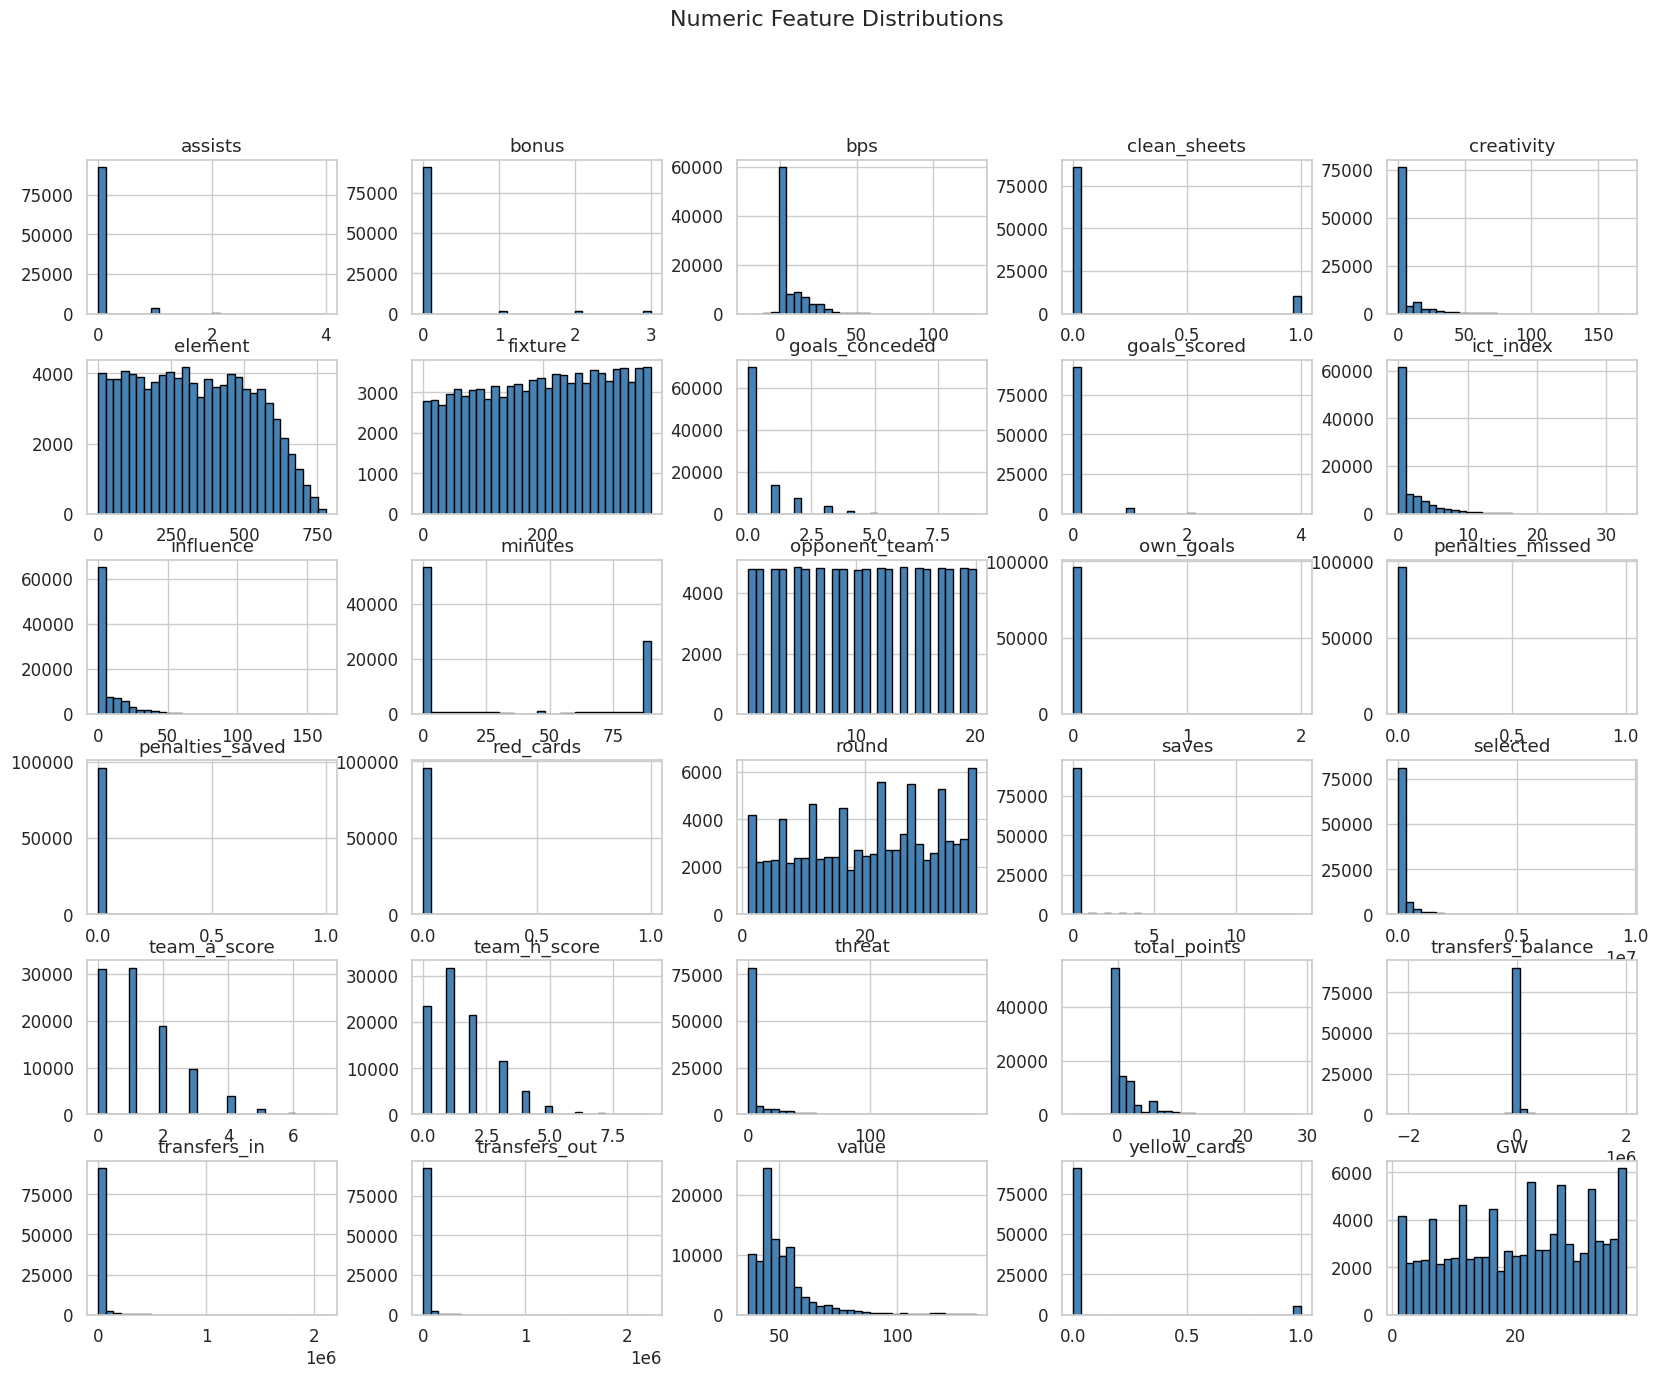

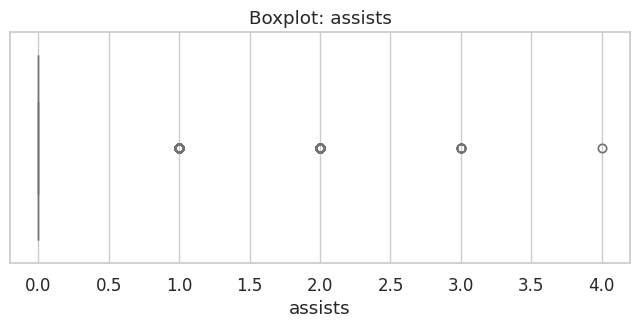

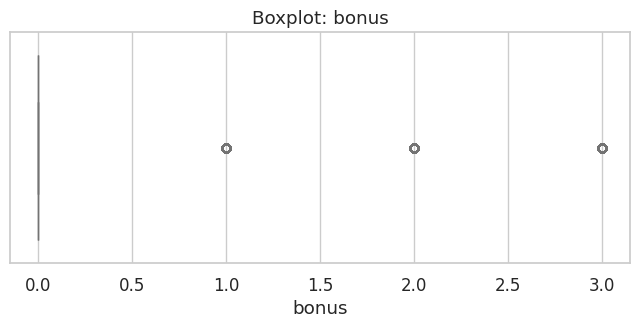

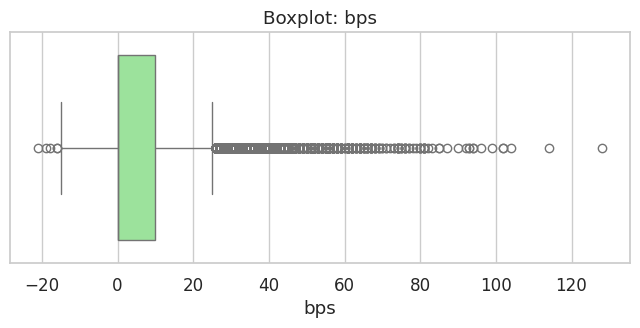

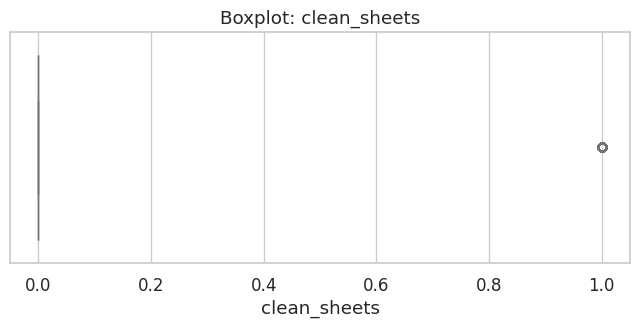

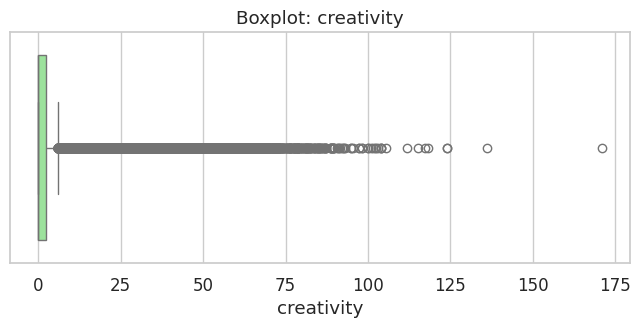

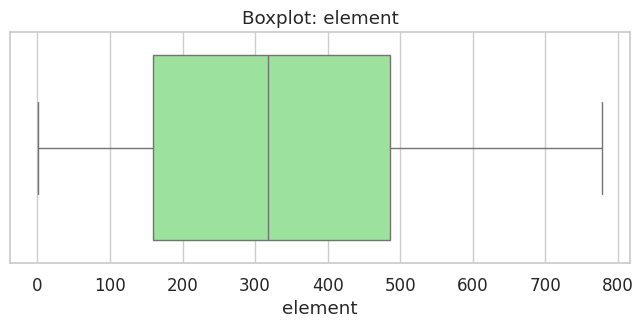

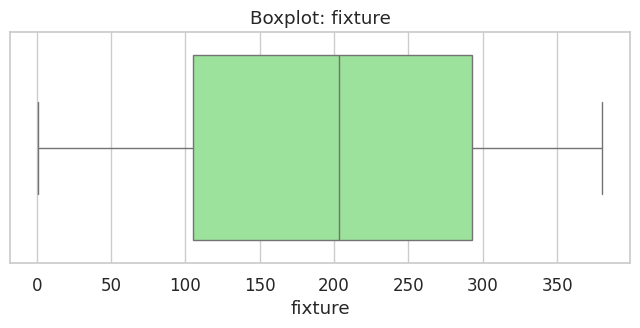

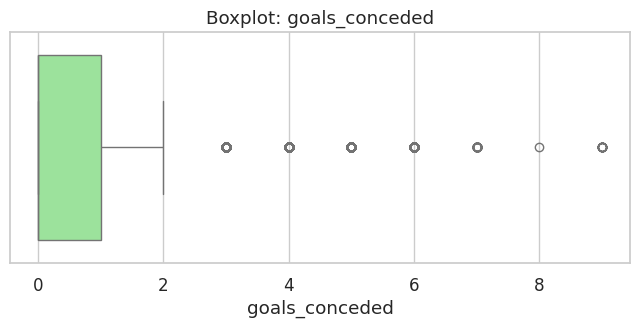

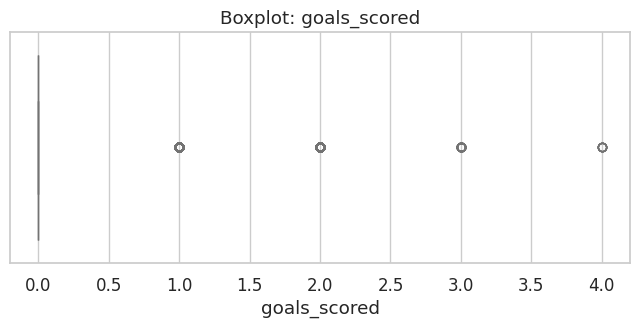

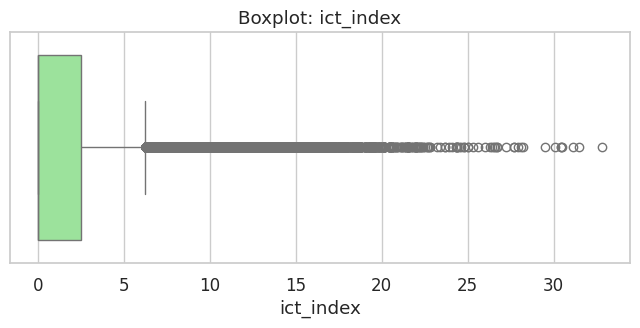

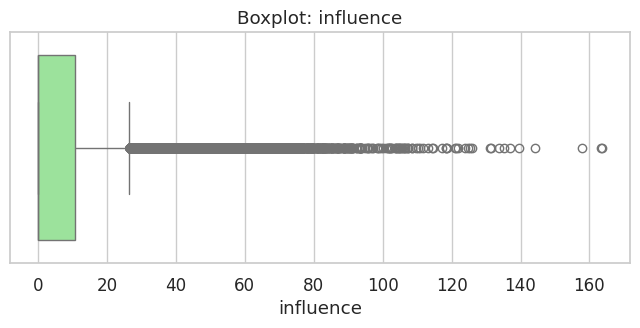

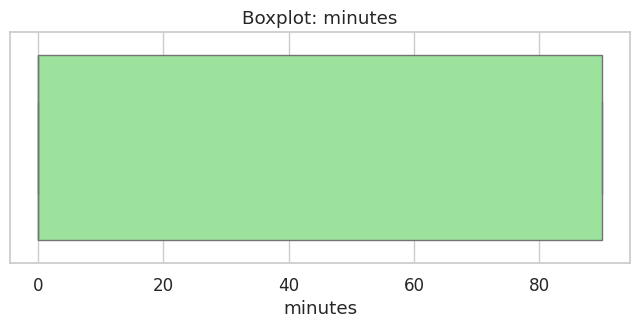

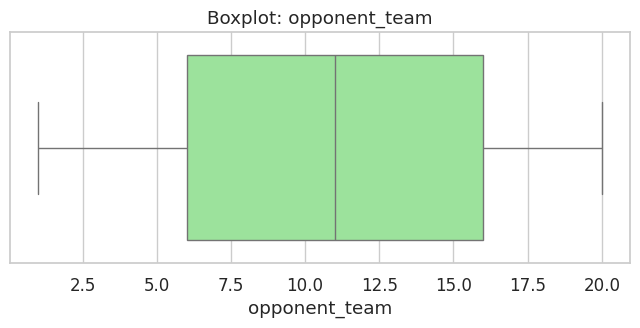

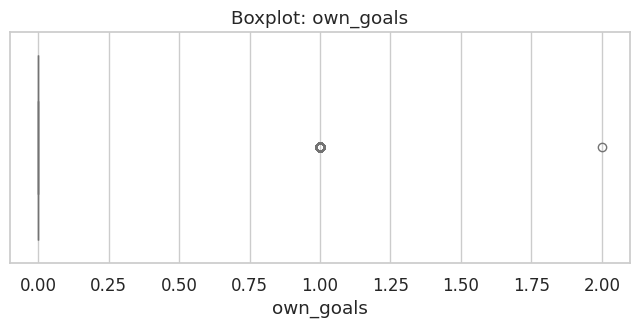

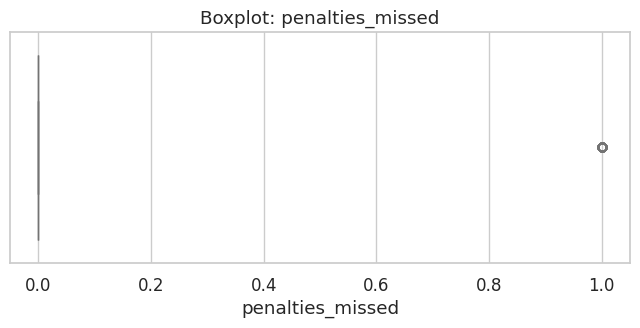

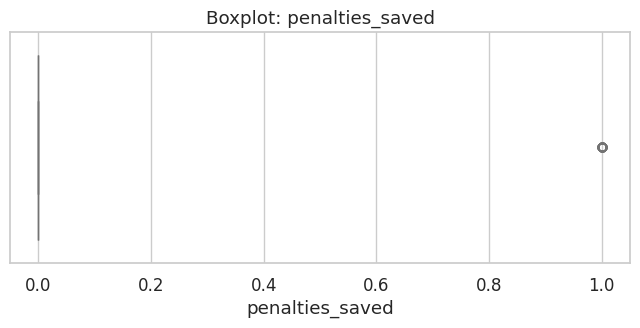

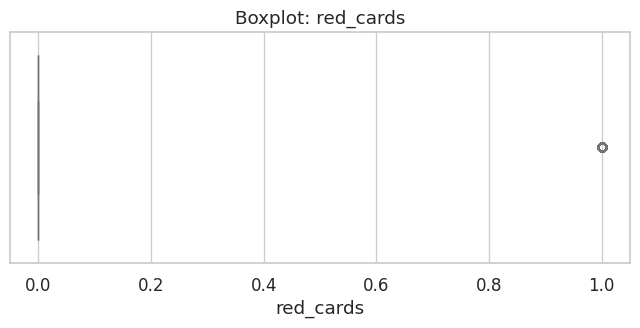

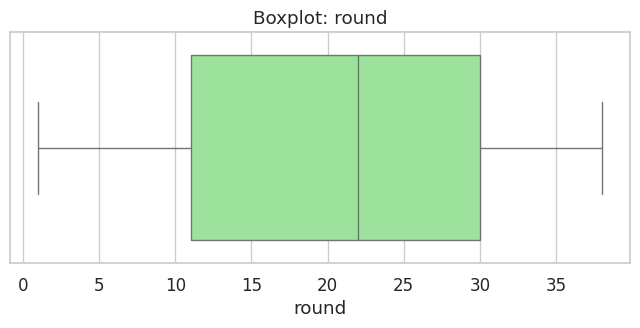

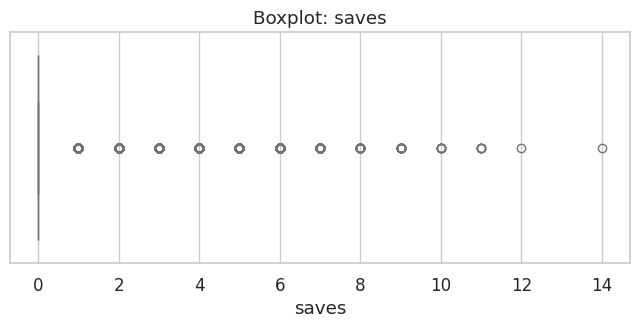

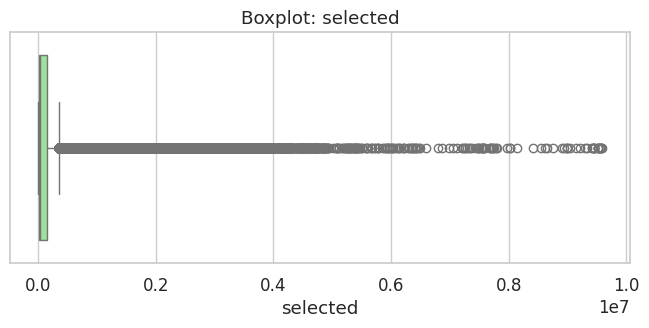

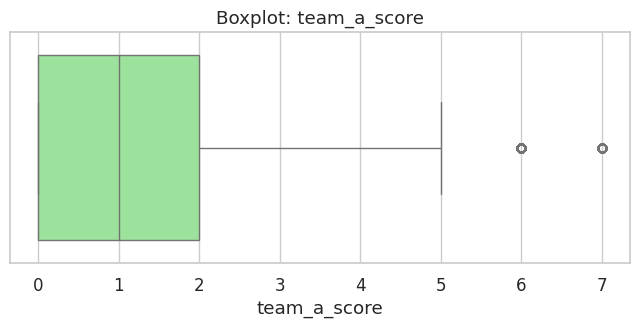

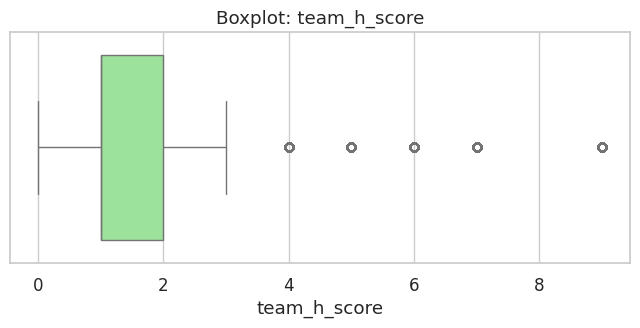

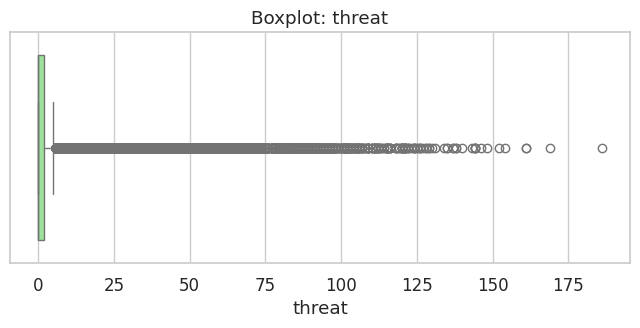

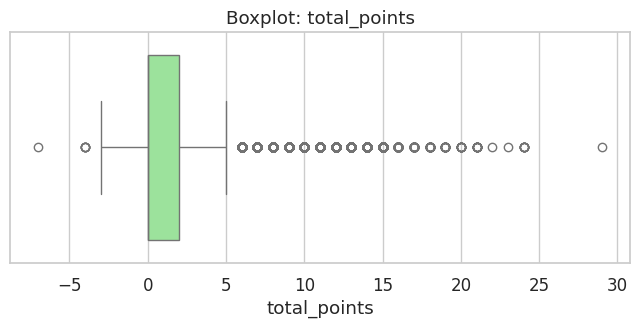

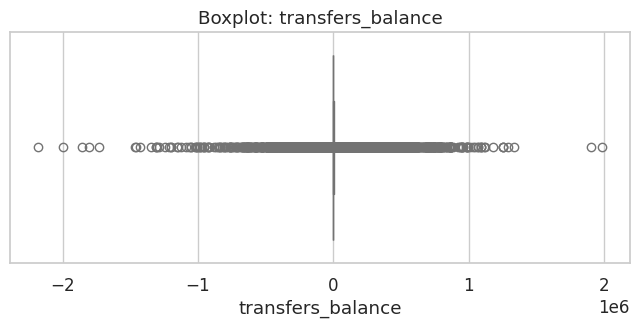

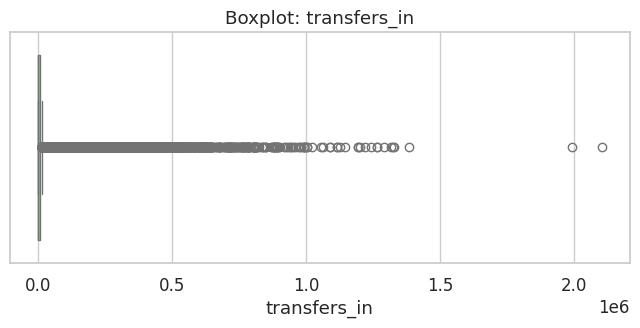

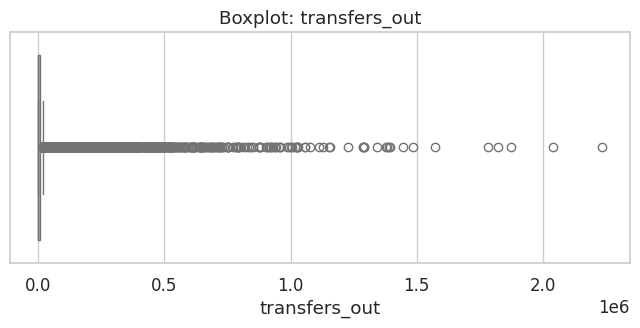

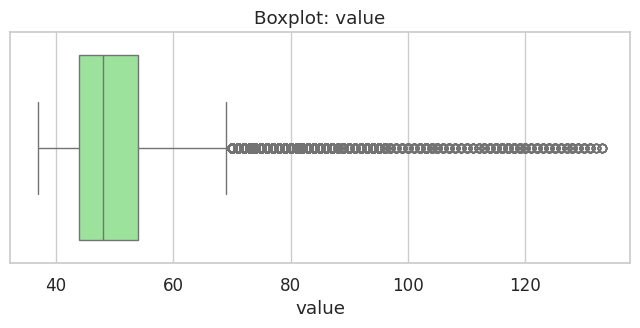

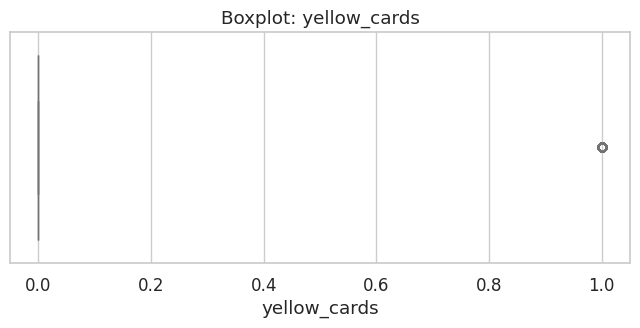

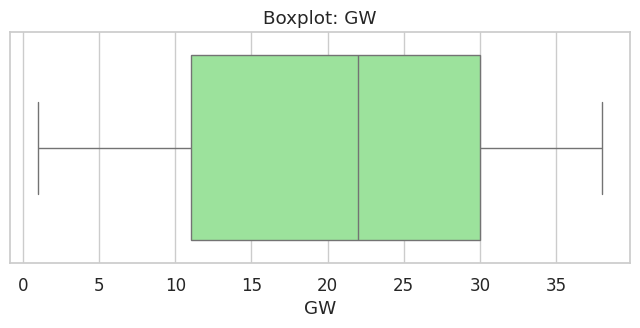

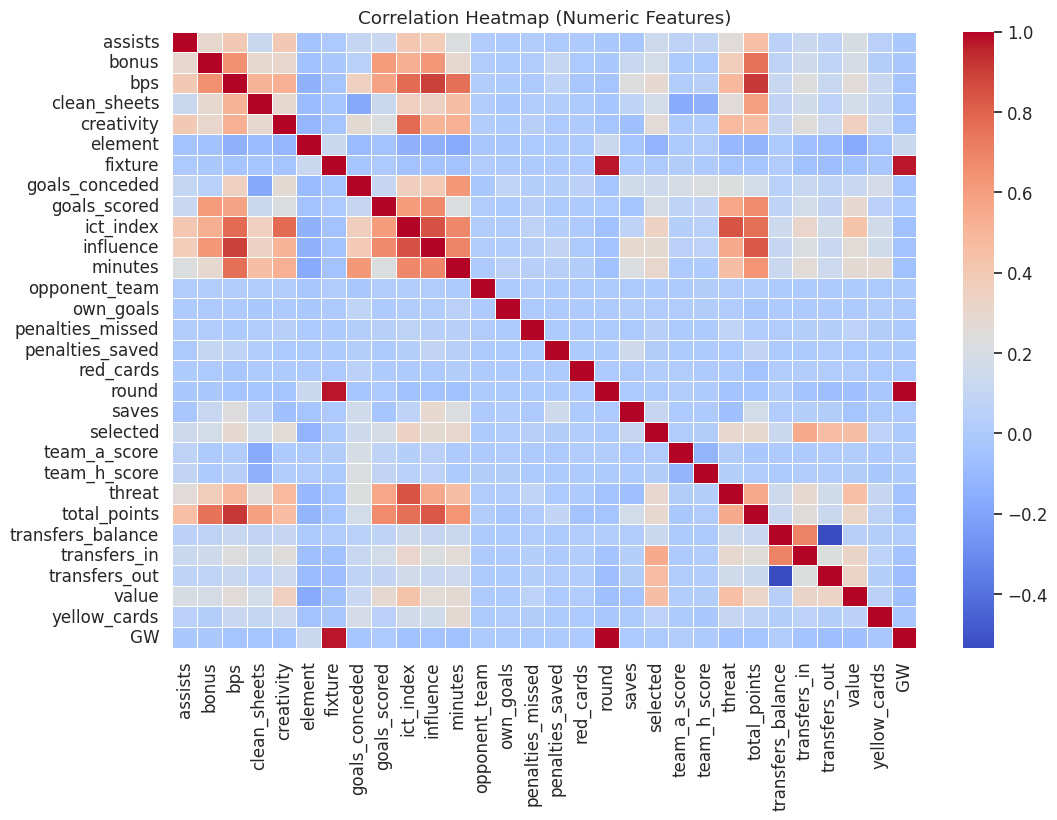


Categorical features (7): ['season_x', 'name', 'position', 'team_x', 'kickoff_time', 'opp_team_name', 'was_home']


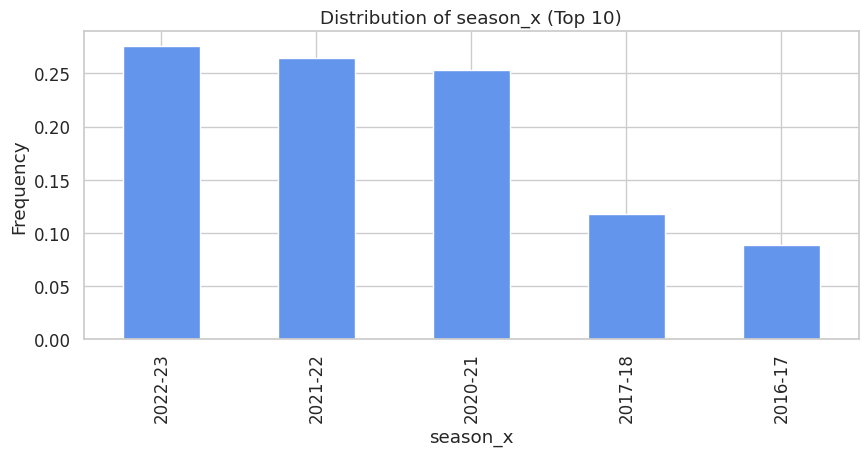

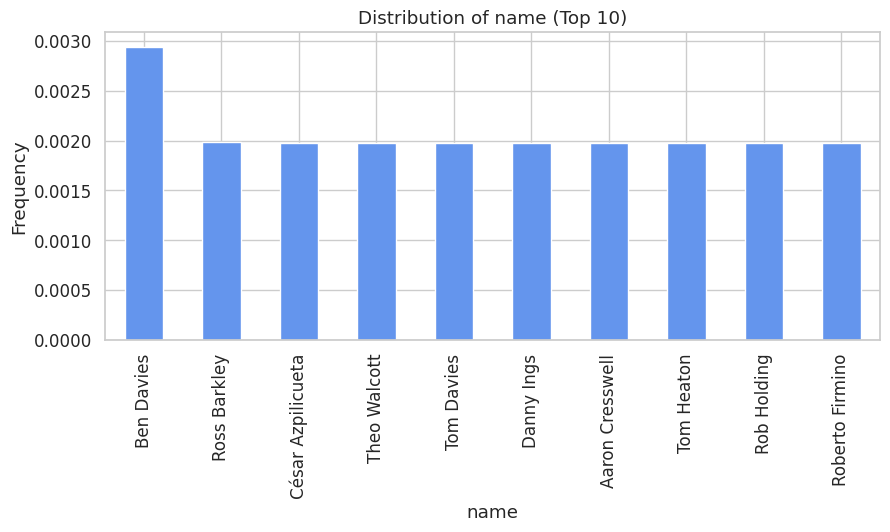

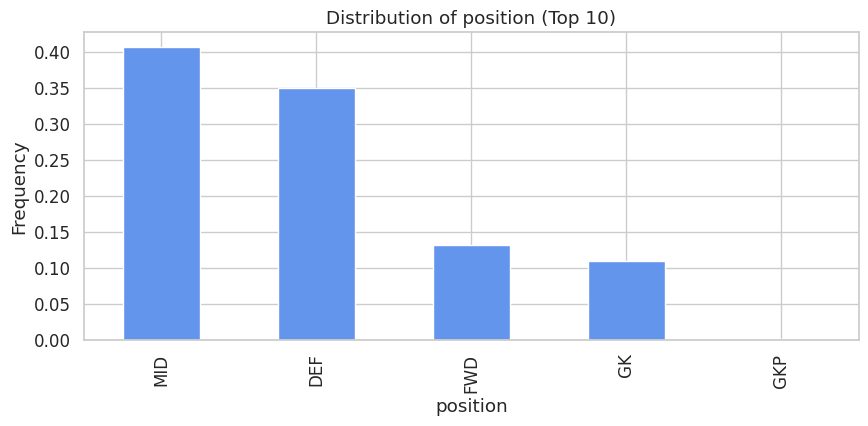

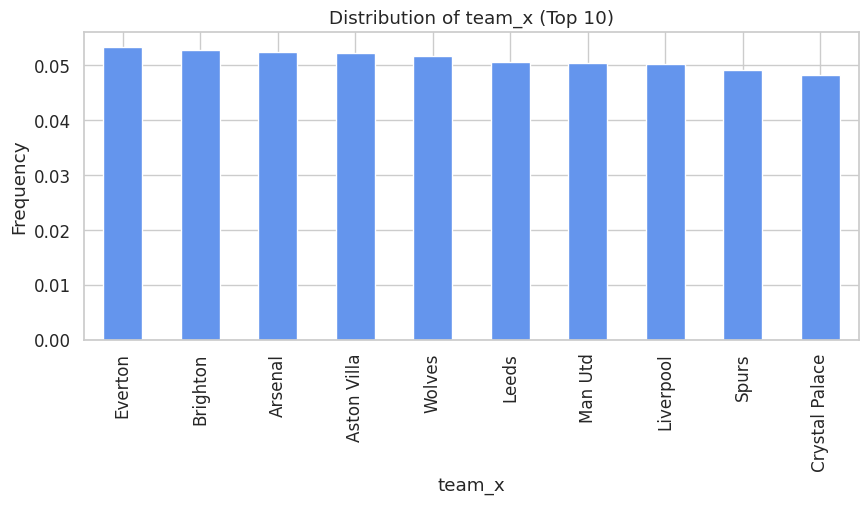

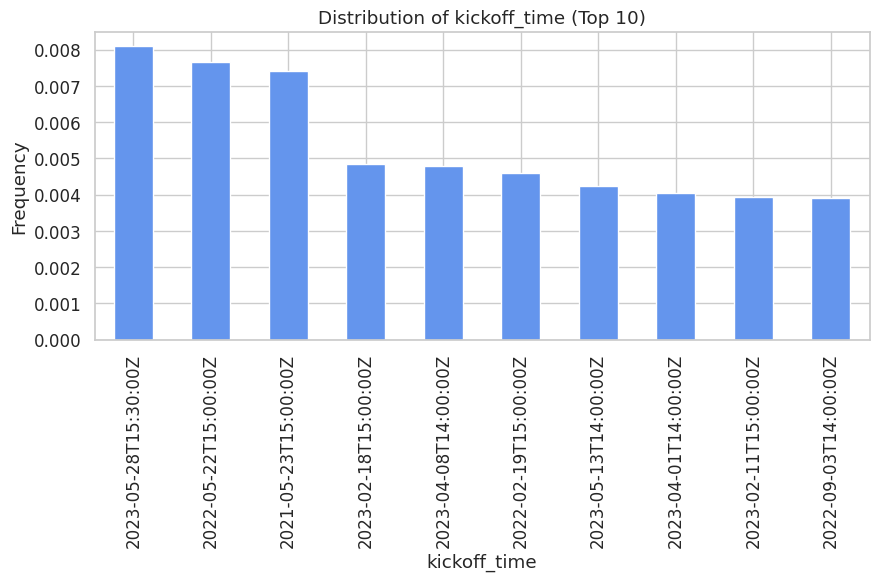

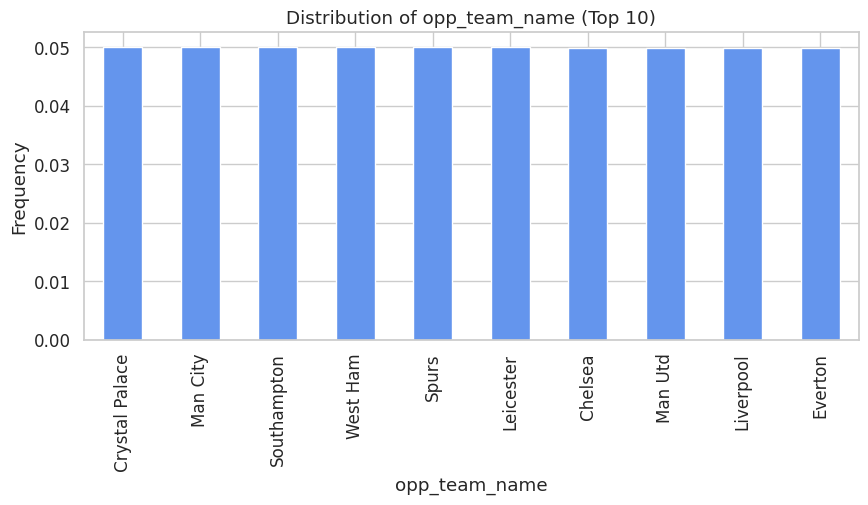

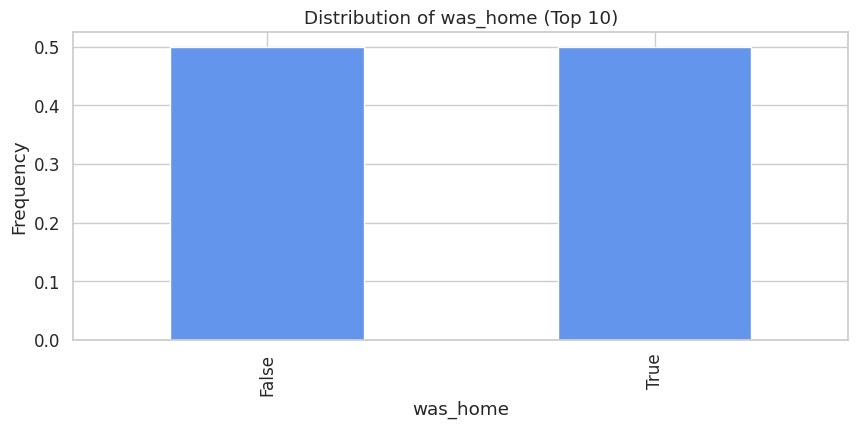


Top correlations with total_points:
bps             0.910722
influence       0.826769
ict_index       0.758720
bonus           0.750068
goals_scored    0.666583
minutes         0.639937
clean_sheets    0.587065
threat          0.552159
creativity      0.471666
assists         0.454027
Name: total_points, dtype: float64


/tmp/ipykernel_97735/205976533.py:70: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




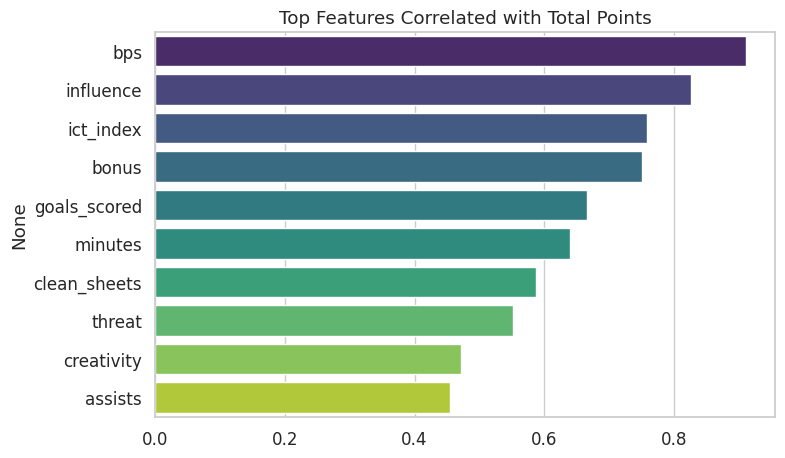

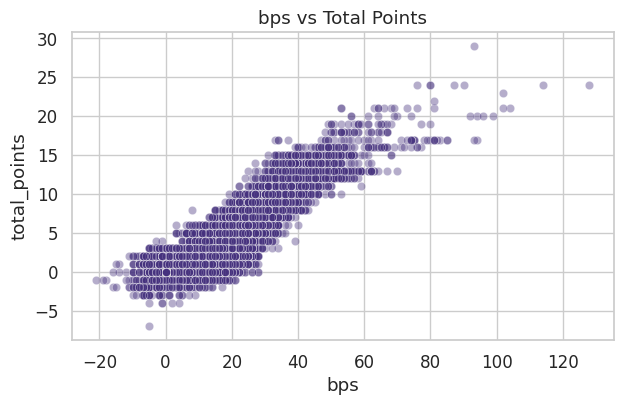

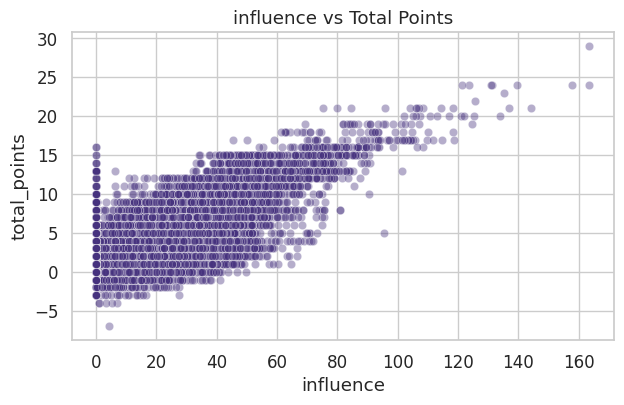

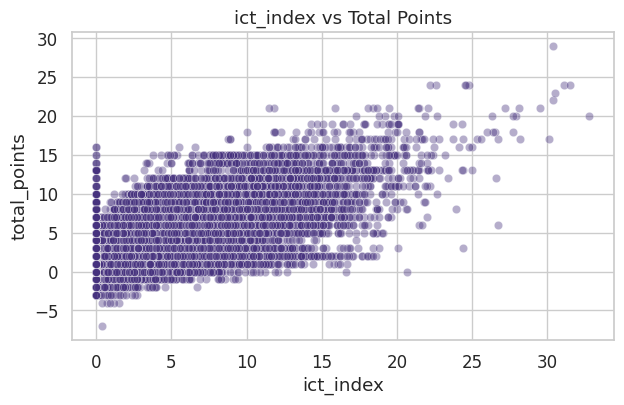

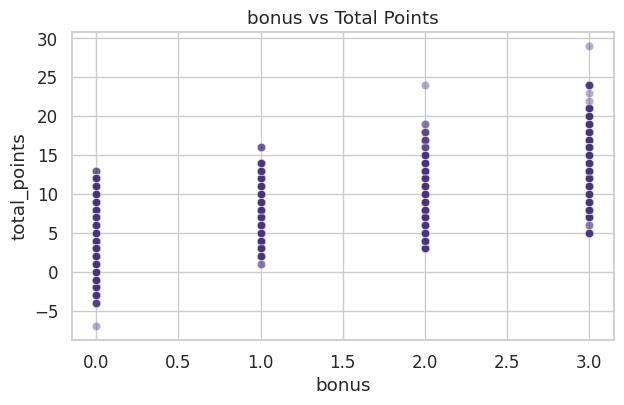

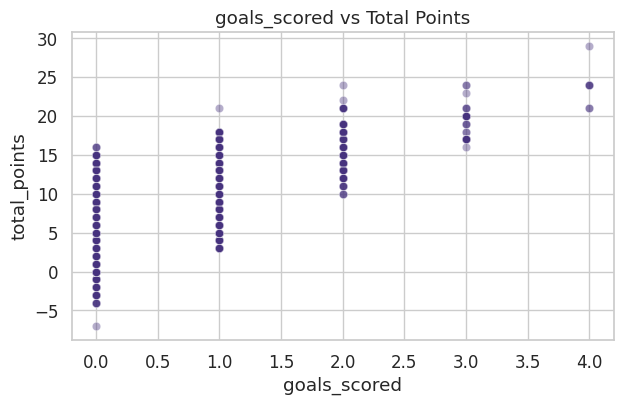

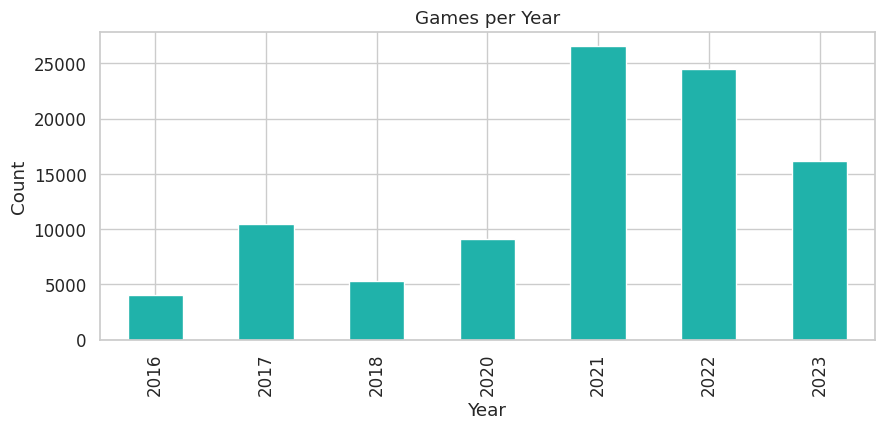

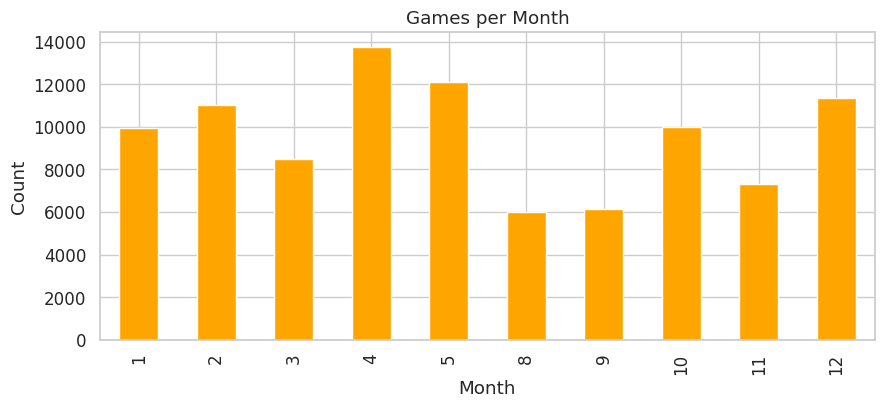


✅ EDA Completed.


In [12]:
full_eda(df)

In [13]:
df_trial = df[df.groupby(["season_x", "element"])["minutes"].transform("sum") > 0]

print("after_filter", len(df_trial), "b4", len(df))

after_filter 76273 b4 96169



===== BASIC INFO =====
<class 'pandas.core.frame.DataFrame'>
Index: 76273 entries, 0 to 96168
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   season_x           76273 non-null  object             
 1   name               76273 non-null  object             
 2   position           76273 non-null  object             
 3   team_x             57988 non-null  object             
 4   assists            76273 non-null  int64              
 5   bonus              76273 non-null  int64              
 6   bps                76273 non-null  int64              
 7   clean_sheets       76273 non-null  int64              
 8   creativity         76273 non-null  float64            
 9   element            76273 non-null  int64              
 10  fixture            76273 non-null  int64              
 11  goals_conceded     76273 non-null  int64              
 12  goals_scored       76273 no

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
season_x,76273,5,2022-23,19584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,76273,982,Angelo Ogbonna,190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
position,76273,5,MID,32266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team_x,57988,25,Everton,3097,NaN,NaN,NaN,NaN,NaN,NaN,NaN
assists,76273.0,NaN,NaN,NaN,0.051748,0.0,0.0,0.0,0.0,4.0,0.240695
bonus,76273.0,NaN,NaN,NaN,0.137073,0.0,0.0,0.0,0.0,3.0,0.549304
bps,76273.0,NaN,NaN,NaN,7.666369,-21.0,0.0,3.0,13.0,128.0,10.496955
clean_sheets,76273.0,NaN,NaN,NaN,0.134582,0.0,0.0,0.0,0.0,1.0,0.341279
creativity,76273.0,NaN,NaN,NaN,5.968875,0.0,0.0,0.1,6.3,170.9,11.692371
element,76273.0,NaN,NaN,NaN,306.393586,1.0,148.0,296.0,456.0,778.0,183.66129



Numeric features (30): ['assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'minutes', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'round', 'saves', 'selected', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'yellow_cards', 'GW']


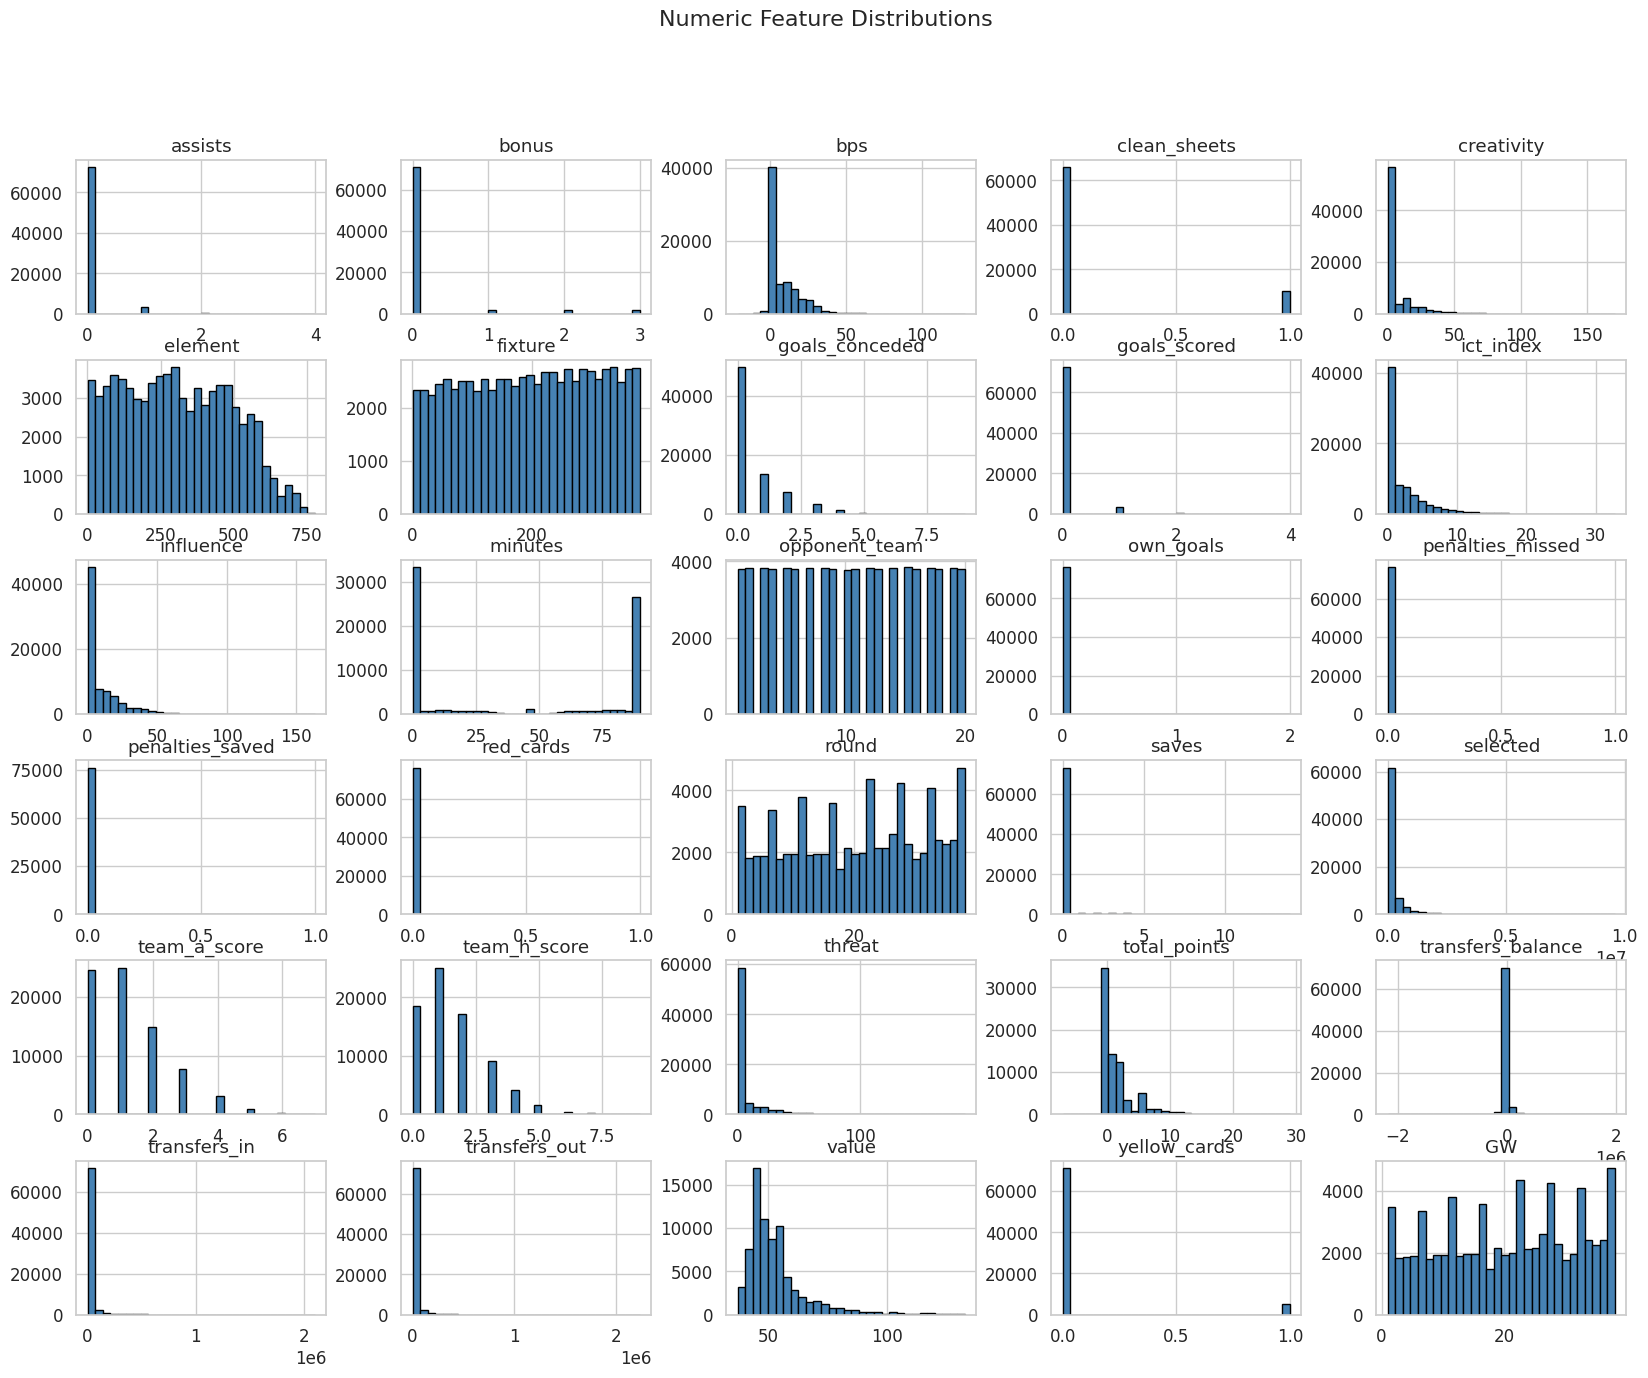

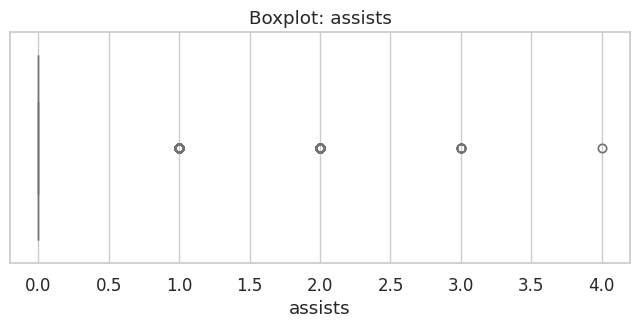

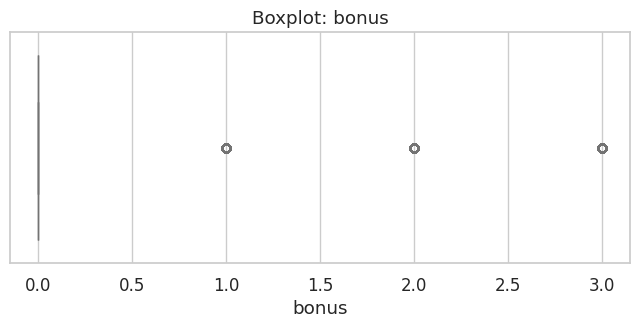

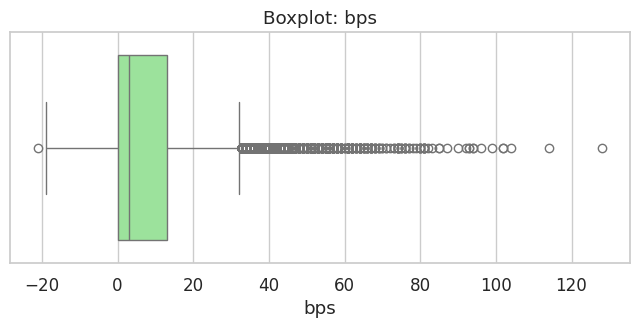

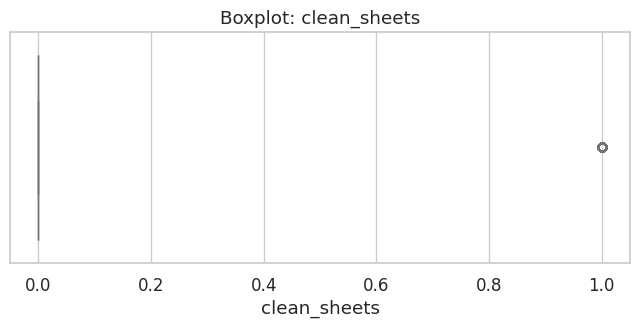

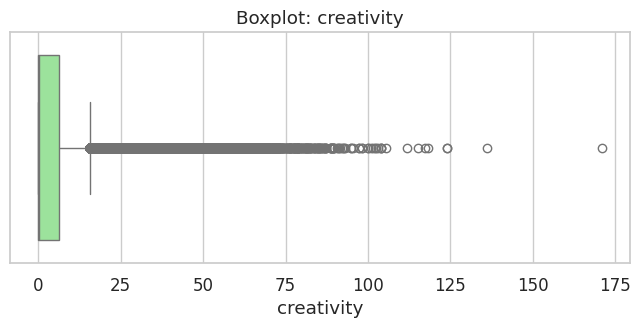

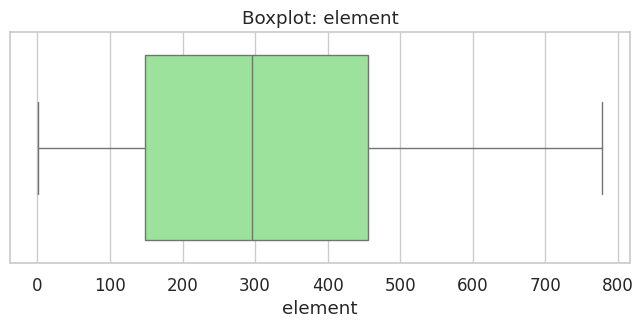

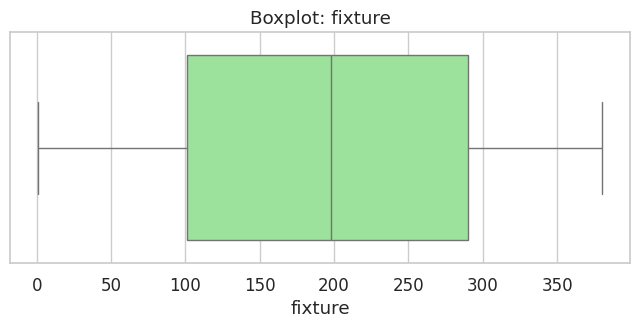

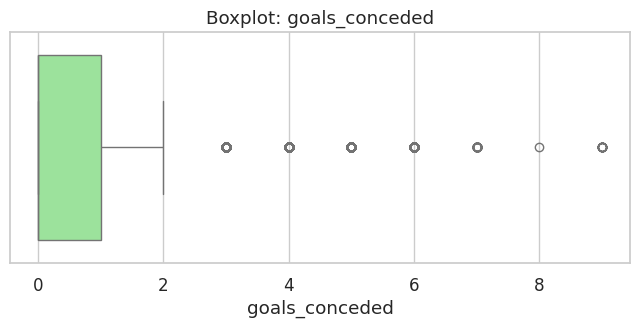

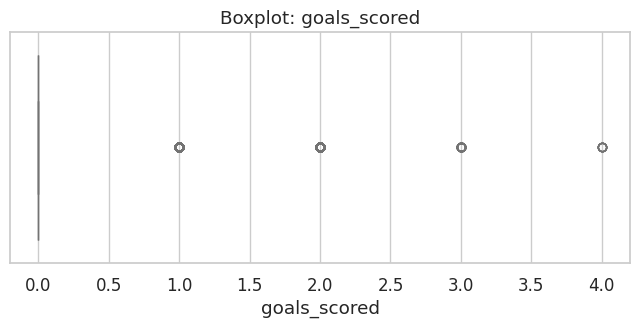

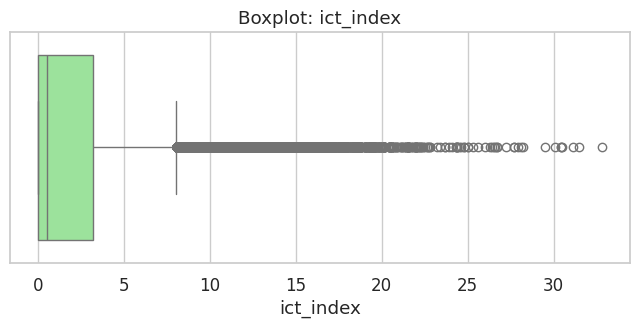

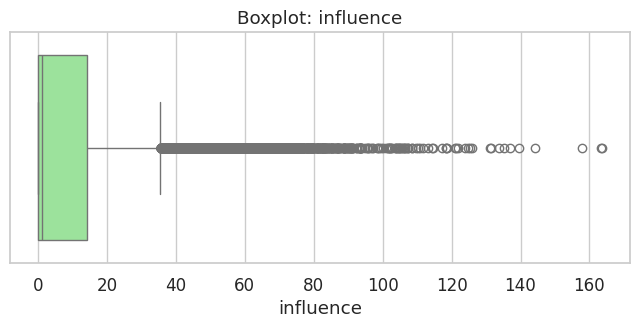

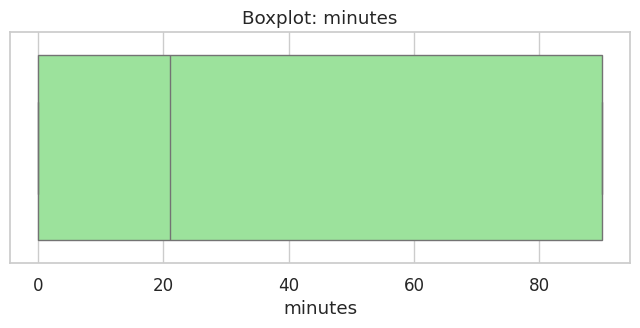

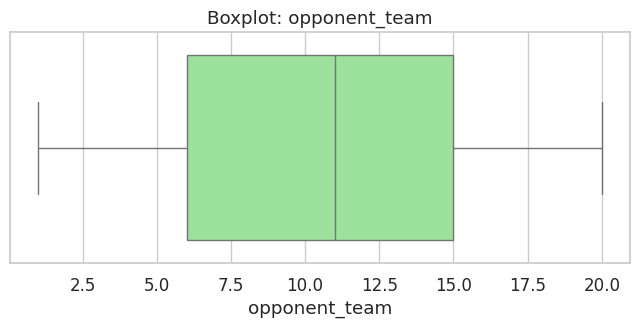

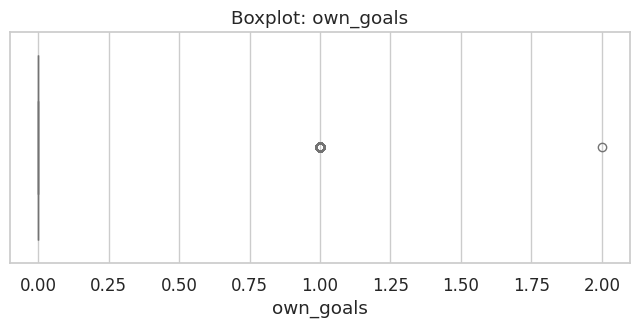

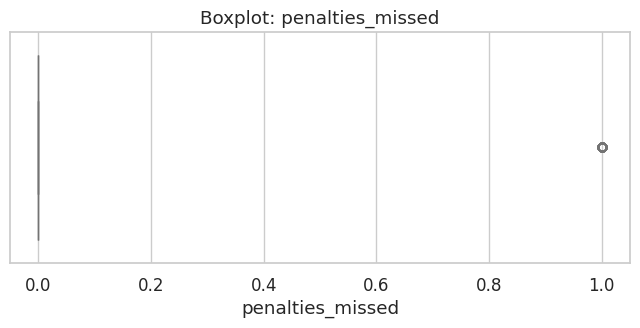

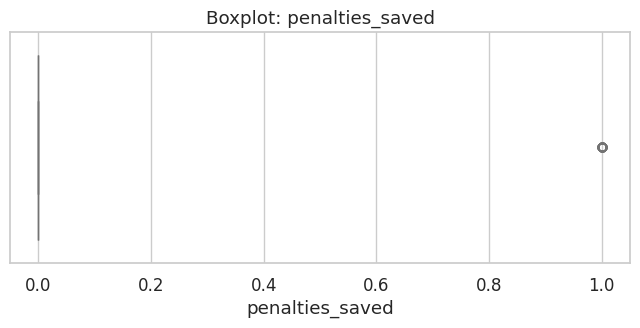

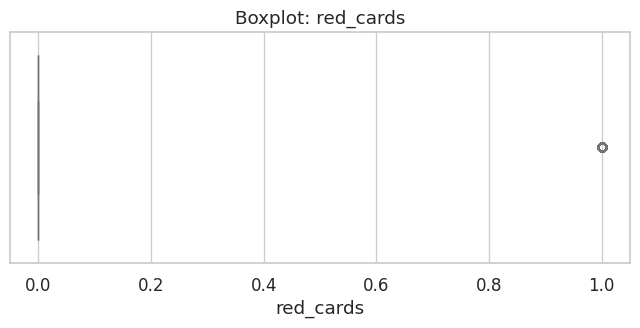

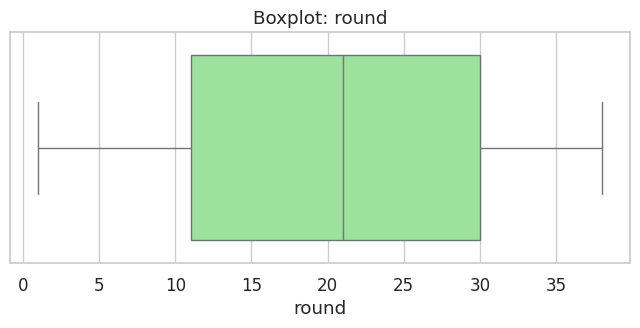

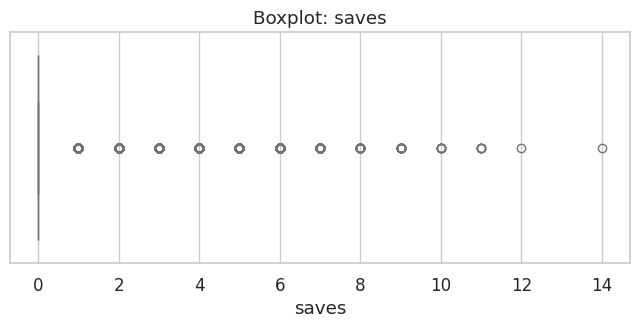

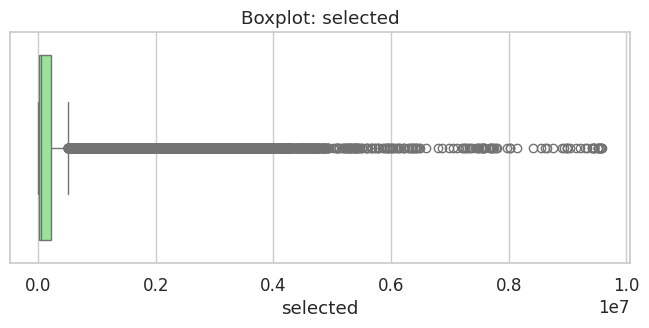

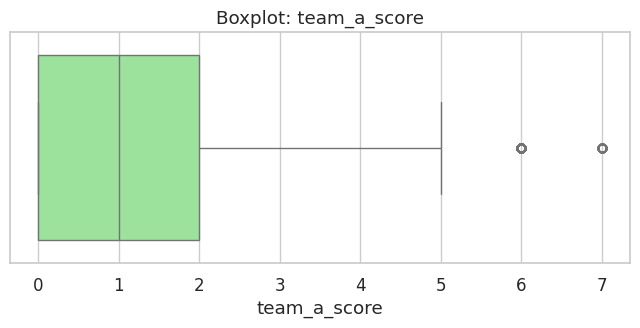

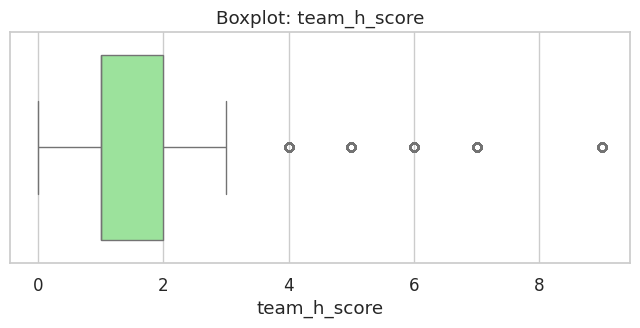

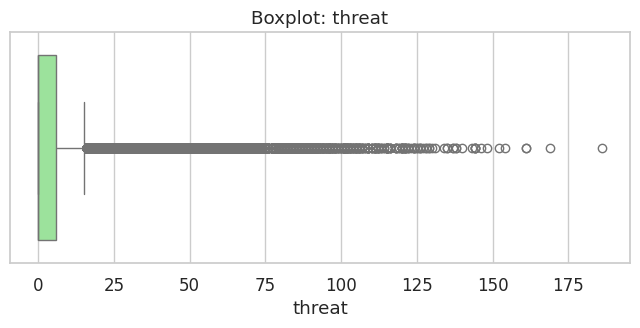

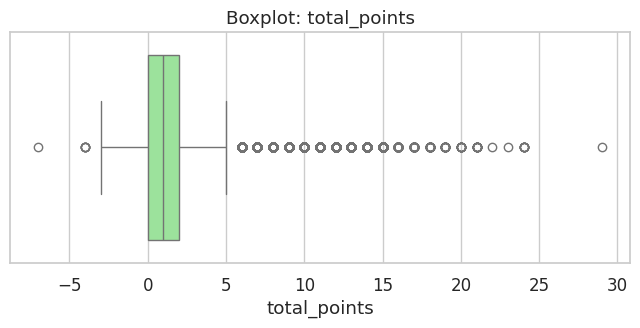

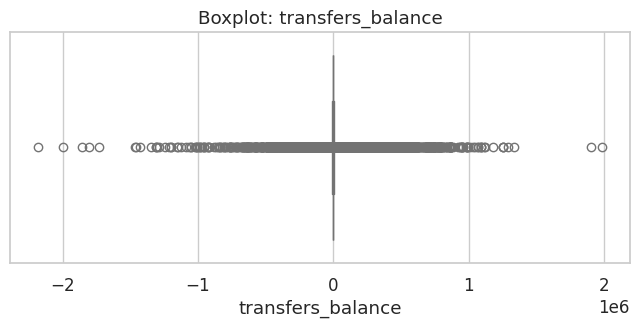

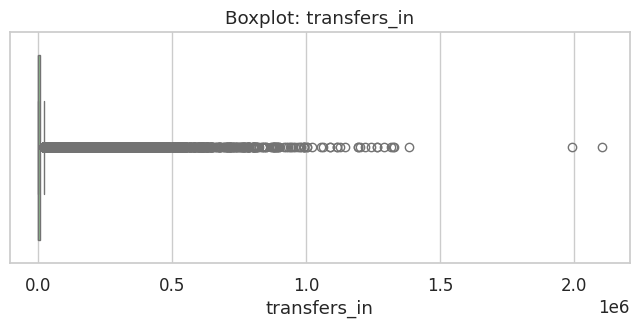

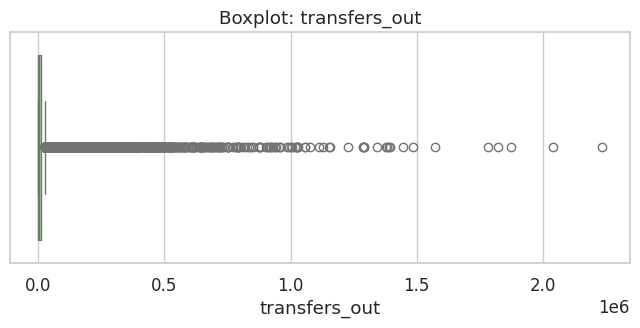

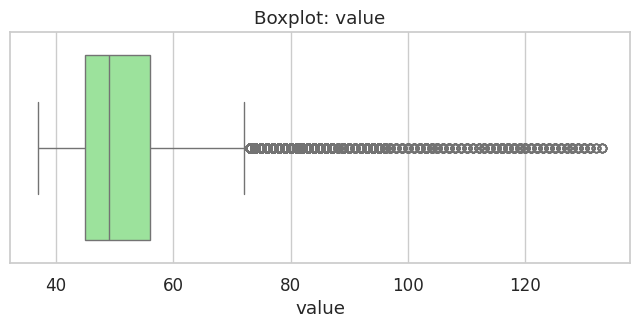

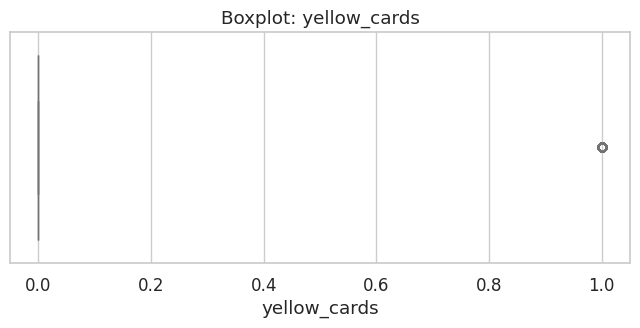

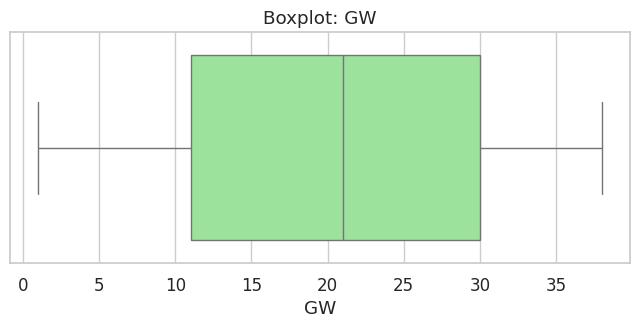

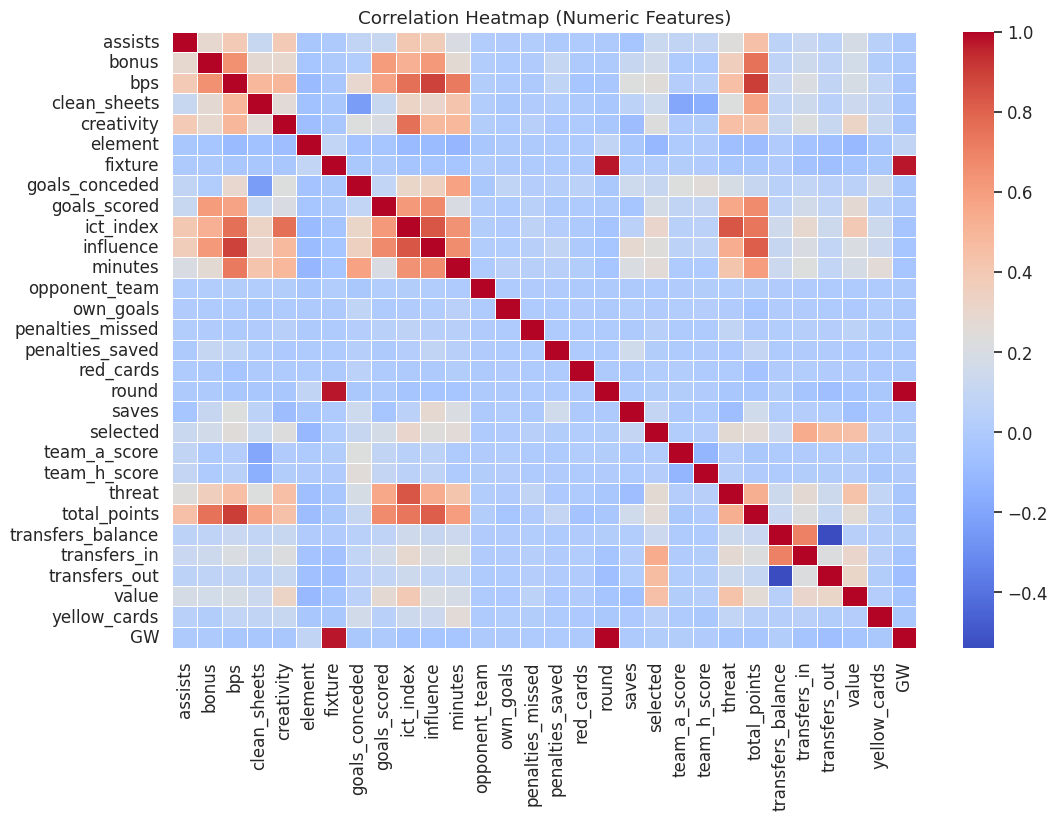


Categorical features (6): ['season_x', 'name', 'position', 'team_x', 'opp_team_name', 'was_home']


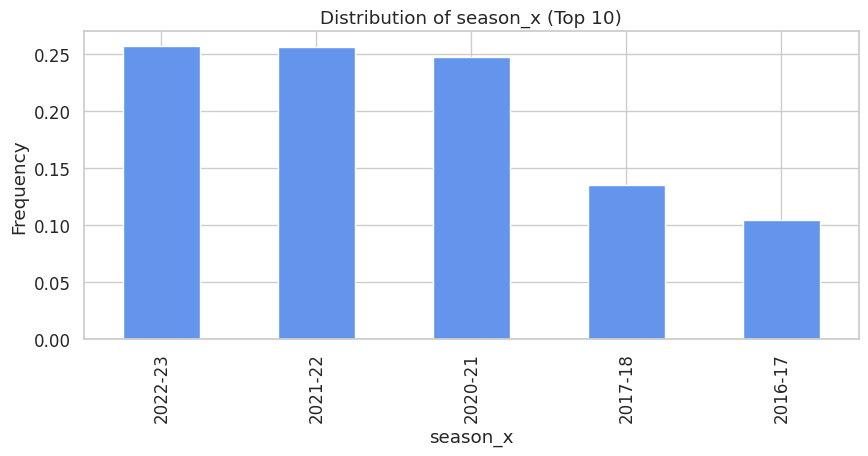

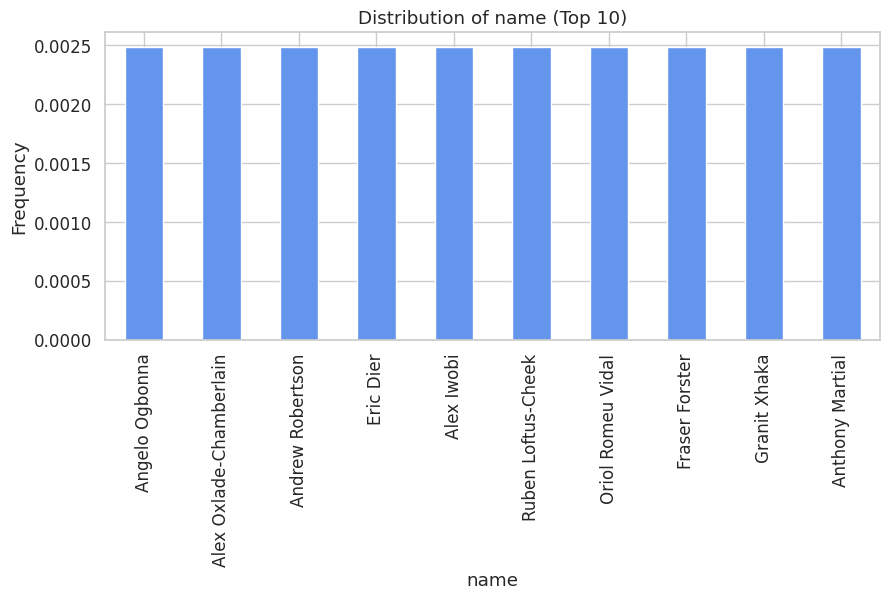

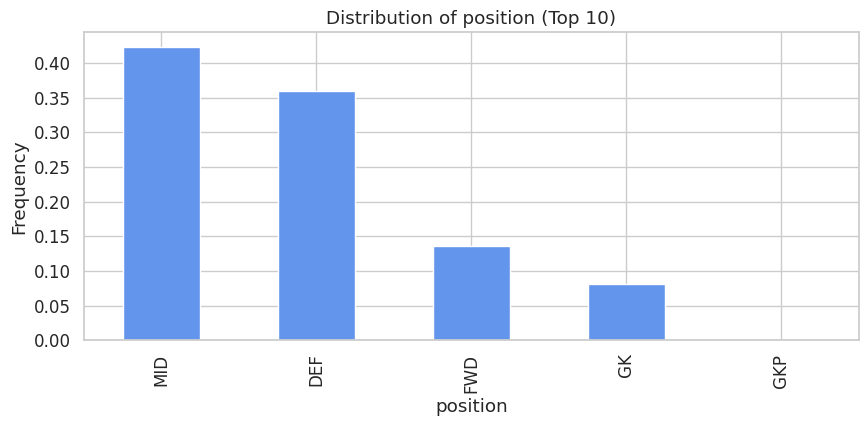

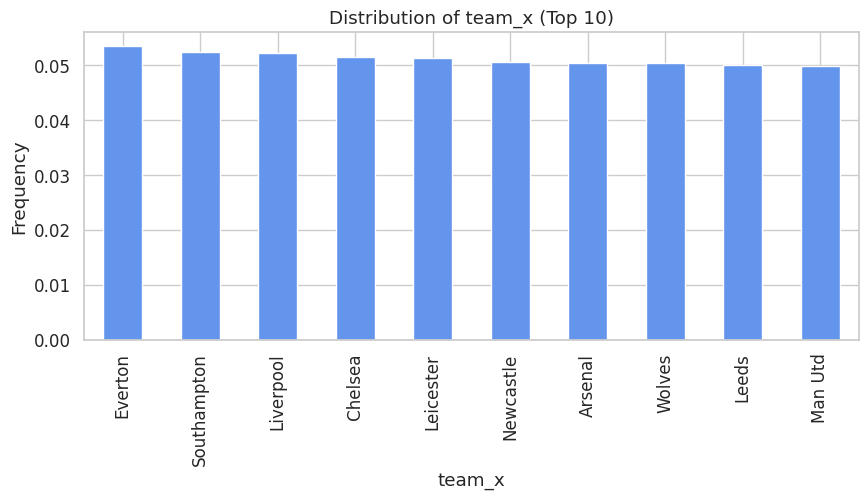

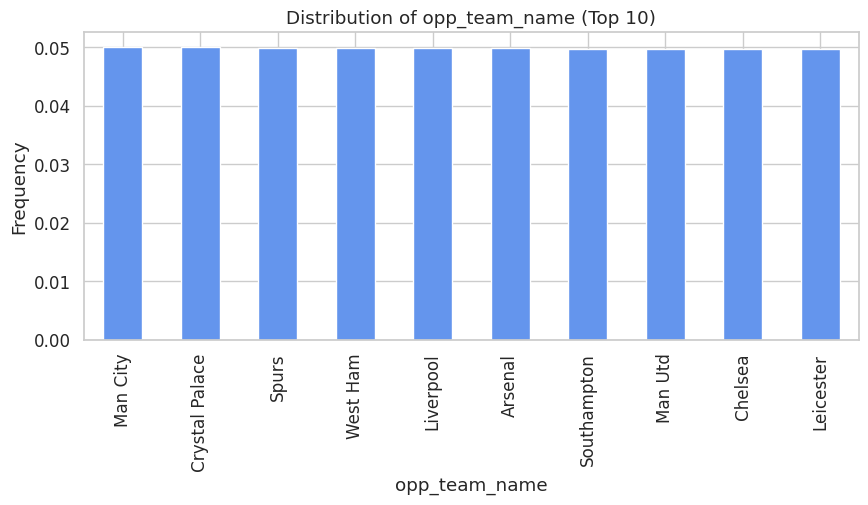

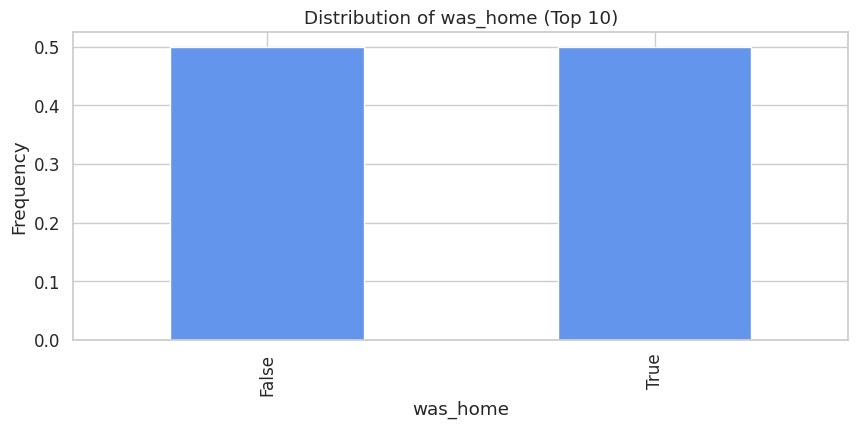


Top correlations with total_points:
bps             0.902968
influence       0.812021
bonus           0.752914
ict_index       0.737848
goals_scored    0.668372
minutes         0.600611
clean_sheets    0.569014
threat          0.527276
assists         0.446582
creativity      0.436987
Name: total_points, dtype: float64


/tmp/ipykernel_97735/205976533.py:70: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




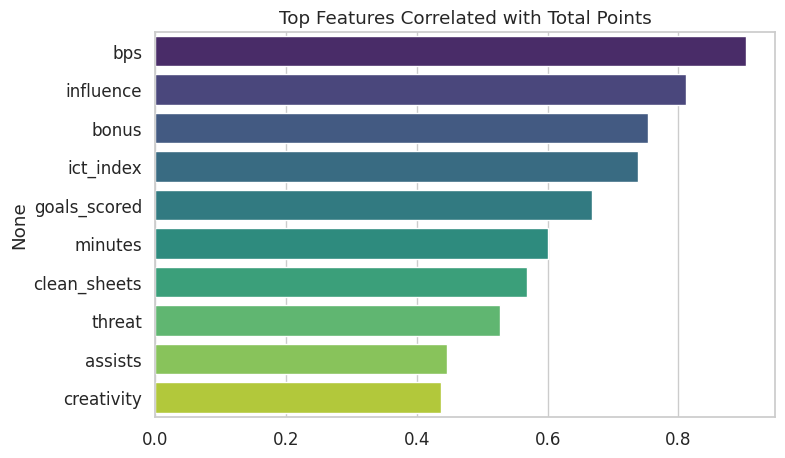

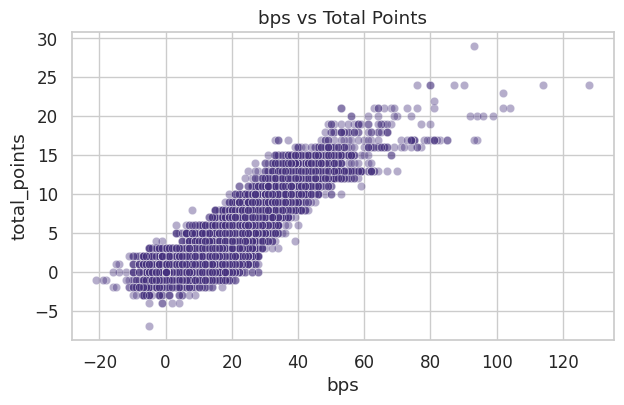

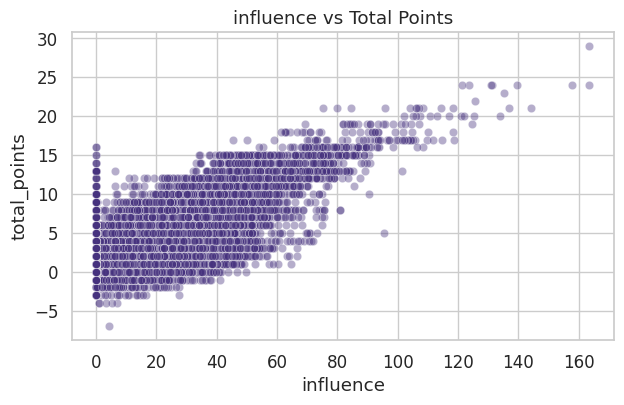

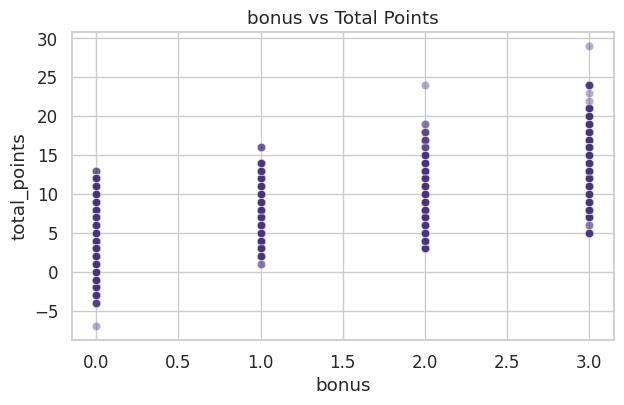

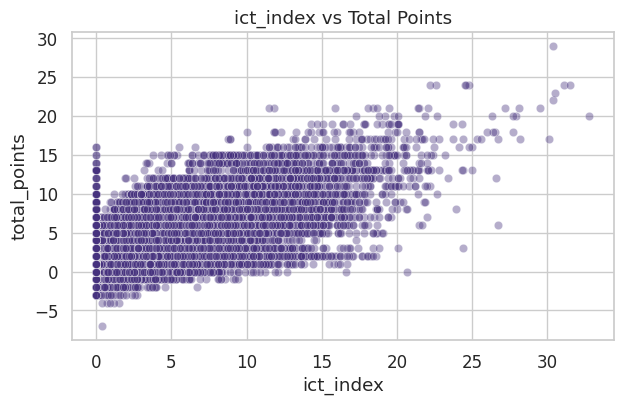

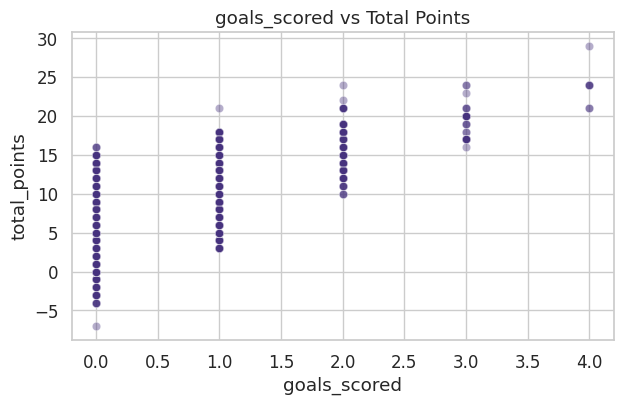

/tmp/ipykernel_97735/205976533.py:85: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_97735/205976533.py:86: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_97735/205976533.py:87: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



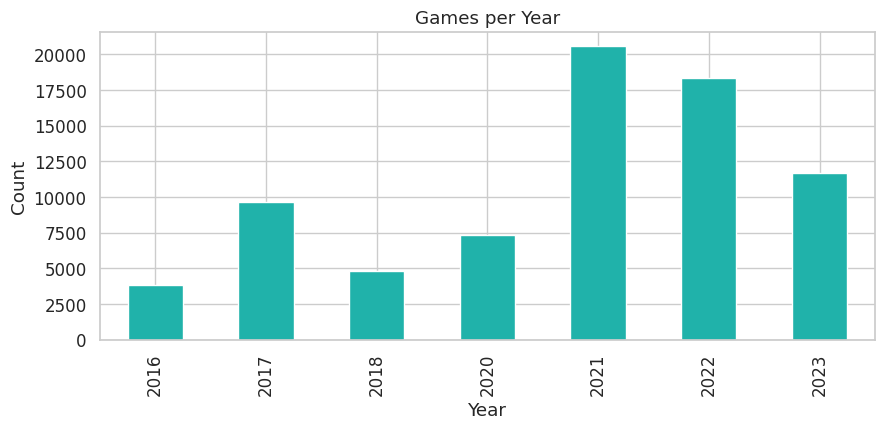

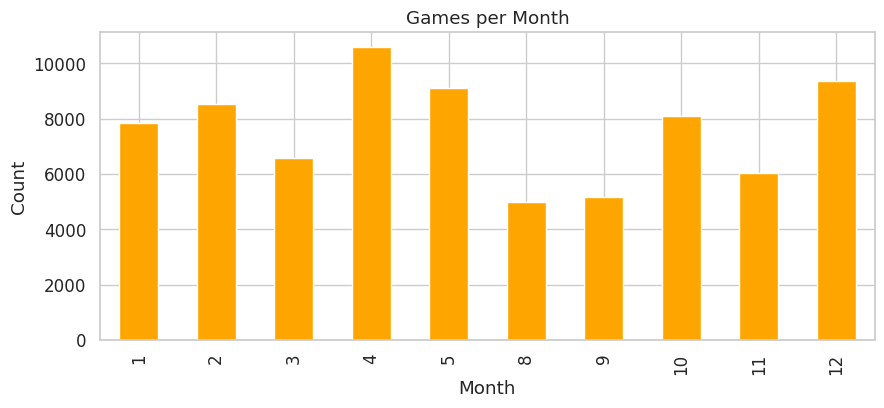


✅ EDA Completed.


In [14]:
full_eda(df_trial)

In [15]:
FPL_POINTS_MULTIPLIERS = {
    "GK": {
        "played_up_to_60_mins": 1,
        "played_60_plus_mins": 2,
        "goal_scored": 6,
        "assist": 3,
        "clean_sheet": 4,
        "penalty_save": 5,
        "every_3_saves": 1,
        "goals_conceded_per_2": -1,
        "yellow_card": -1,
        "red_card": -3,
        "own_goal": -2,
        "penalty_miss": -2,
        "defensive_contributions_2pts": 0,  # Does not apply for GK
    },
    "DEF": {
        "played_up_to_60_mins": 1,
        "played_60_plus_mins": 2,
        "goal_scored": 6,
        "assist": 3,
        "clean_sheet": 4,
        "penalty_save": 0,
        "every_3_saves": 0,
        "goals_conceded_per_2": -1,
        "yellow_card": -1,
        "red_card": -3,
        "own_goal": -2,
        "penalty_miss": -2,
        "defensive_contributions_2pts": 2,  # For 10+ clearances/blocks/interceptions/tackles
    },
    "MID": {
        "played_up_to_60_mins": 1,
        "played_60_plus_mins": 2,
        "goal_scored": 5,
        "assist": 3,
        "clean_sheet": 1,
        "penalty_save": 0,
        "every_3_saves": 0,
        "goals_conceded_per_2": 0,
        "yellow_card": -1,
        "red_card": -3,
        "own_goal": -2,
        "penalty_miss": -2,
        "defensive_contributions_2pts": 2,  # For 12+ clearances/blocks/interceptions/tackles/recoveries
    },
    "FWD": {
        "played_up_to_60_mins": 1,
        "played_60_plus_mins": 2,
        "goal_scored": 4,
        "assist": 3,
        "clean_sheet": 0,
        "penalty_save": 0,
        "every_3_saves": 0,
        "goals_conceded_per_2": 0,
        "yellow_card": -1,
        "red_card": -3,
        "own_goal": -2,
        "penalty_miss": -2,
        "defensive_contributions_2pts": 2,  # For 12+ clearances/blocks/interceptions/tackles/recoveries
    },
}

In [16]:
def calculate_fpl_points(df, positions):
    df_temp = df.copy()
    for position in positions:
        mask = df["position"] == position
        df_temp.loc[mask, "fpl_points"] = (
            df_temp.loc[mask, "assists"] * FPL_POINTS_MULTIPLIERS[position]["assist"]
            + df_temp.loc[mask, "bonus"]
            + df_temp.loc[mask, "clean_sheets"]
            * FPL_POINTS_MULTIPLIERS[position]["clean_sheet"]
            + df_temp.loc[mask, "goals_conceded"]
            // 2
            * FPL_POINTS_MULTIPLIERS[position]["goals_conceded_per_2"]
            + df_temp.loc[mask, "goals_scored"]
            * FPL_POINTS_MULTIPLIERS[position]["goal_scored"]
            + (df_temp.loc[mask, "minutes"] >= 60) * 2
            + ((df_temp.loc[mask, "minutes"] > 0) & (df_temp.loc[mask, "minutes"] < 60))
            * 1
            + df_temp.loc[mask, "own_goals"]
            * FPL_POINTS_MULTIPLIERS[position]["own_goal"]
            + df_temp.loc[mask, "penalties_missed"]
            * FPL_POINTS_MULTIPLIERS[position]["penalty_miss"]
            + df_temp.loc[mask, "penalties_saved"]
            * FPL_POINTS_MULTIPLIERS[position]["penalty_save"]
            + df_temp.loc[mask, "red_cards"]
            * FPL_POINTS_MULTIPLIERS[position]["red_card"]
            + (df_temp.loc[mask, "saves"] // 3)
            * FPL_POINTS_MULTIPLIERS[position]["every_3_saves"]
            + df_temp.loc[mask, "yellow_cards"]
            * FPL_POINTS_MULTIPLIERS[position]["yellow_card"]
        )
    return df_temp

In [17]:
df_comparison_before = calculate_fpl_points(df, ["GK", "DEF", "MID", "FWD"])
df_comparison_before[
    df_comparison_before["fpl_points"] != df_comparison_before["total_points"]
]["name"].value_counts()

,count
name,
Eric Dier,44
Fernando Luiz Rosa,35
Marcus Rashford,26
Anthony Martial,25
Michail Antonio,23
...,...
Jonas Lössl,1
Robert Sánchez,1
David Raya Martin,1


Example of a single match
In which if is a defender then the goals conceded should result in a -1 but it does not, leaving him with 2 points (>=60 minutes played)
Therefore this player was a MID on that season not a DEF

In [18]:
df_comparison_before[
    (df_comparison_before["fpl_points"] != df_comparison_before["total_points"])
    & (df["name"] == "Eric Dier")
].iloc[0]

,697
season_x,2016-17
name,Eric Dier
position,DEF
team_x,NaN
assists,0
bonus,0
bps,19
clean_sheets,0
creativity,1.2
element,390


In [19]:
last_number_gws = 4

# Data Cleaning

In [20]:
df_copy = df.copy()
print("init_shape", df_copy.shape)
# force keys to be strings to make sure datatypes are compatible when joining
for c in ["season_x", "GW", "fixture"]:
    df_copy[c] = df_copy[c].astype(str)


def teams_in_group(g):
    return set(g["opp_team_name"].dropna().astype(str).unique())


fixture_teams = (
    df_copy.groupby(["season_x", "GW", "fixture"])
    # FIX: Added include_groups=False to silence the DeprecationWarning
    .apply(teams_in_group, include_groups=False)
    .reset_index(name="teams")
)

# Keep only fixtures with exactly 2 distinct teams
fixture_teams = fixture_teams[fixture_teams["teams"].apply(lambda s: len(s) == 2)]

fixture_teams[["team_a", "team_b"]] = fixture_teams["teams"].apply(
    lambda s: pd.Series(sorted(list(s)))
)


df_merged = df_copy.merge(
    fixture_teams[["season_x", "GW", "fixture", "team_a", "team_b"]],
    on=["season_x", "GW", "fixture"],
    how="left",
)

# mask to manage only rows who have team_x as null
mask_null_teamx = df_merged["team_x"].isna() & df_merged["team_a"].notna()

# FIX: Initialize the column with a string-compatible dtype ('object')
# to silence the FutureWarning when assigning team names (strings) later.
df_merged["team_x_inferred"] = np.nan
df_merged["team_x_inferred"] = df_merged["team_x_inferred"].astype("object")


# where opponent == team_a -> set to team_b
mask_a = mask_null_teamx & (
    df_merged["opp_team_name"].astype(str) == df_merged["team_a"]
)
df_merged.loc[mask_a, "team_x_inferred"] = df_merged.loc[mask_a, "team_b"]

# where opponent == team_b -> set to team_a
mask_b = mask_null_teamx & (
    df_merged["opp_team_name"].astype(str) == df_merged["team_b"]
)
df_merged.loc[mask_b, "team_x_inferred"] = df_merged.loc[mask_b, "team_a"]

df_merged["team_x_filled"] = df_merged["team_x"].fillna(df_merged["team_x_inferred"])

df_result = df.copy()
# replace nulls in original team_x with filled values
df_result["team_x"] = df_result["team_x"].fillna(df_merged["team_x_filled"])
print(df_result.shape)
df_result.head()

init_shape (96169, 39)
(96169, 39)


,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,...,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,year,month
0,2016-17,Aaron Cresswell,DEF,West Ham,0,0,0,0,0.0,454,...,0,0,0,0,55,False,0,1,2016,8
1,2016-17,Aaron Lennon,MID,Everton,0,0,6,0,0.3,142,...,1,0,0,0,60,True,0,1,2016,8
2,2016-17,Aaron Ramsey,MID,Arsenal,0,0,5,0,4.9,16,...,2,0,0,0,80,True,0,1,2016,8
3,2016-17,Abdoulaye Doucouré,MID,Watford,0,0,0,0,0.0,482,...,0,0,0,0,50,False,0,1,2016,8
4,2016-17,Adam Forshaw,MID,Middlesbrough,0,0,3,0,1.3,286,...,1,0,0,0,45,True,1,1,2016,8


## Unify Goalkeeper representation

In [21]:
df["position"] = df["position"].replace({"GKP": "GK"})

### Handle Minimum Number of GWS

In [22]:
print("before_filter", len(df))
minimum_gws = 2  # Can change according to performance
df = df[df.groupby(["season_x", "element"])["element"].transform("size") >= minimum_gws]
print("after_filter", len(df))

before_filter 96169
after_filter 96155


## Fixing players with incorrect FPL point (wrong positions)

In [23]:
# Define all position updates in one place
position_updates = [
    {
        "names": ["Jeffrey Schlupp", "Jairo Riedewald", "Declan Rice"],
        "seasons": ["2016-17", "2017-18"],
        "position": "DEF",
    },
    {
        "names": ["James Milner"],
        "seasons": ["2017-18"],
        "position": "DEF",
    },
    {
        "names": [
            "Eric Dier",
            "Fernando Luiz Rosa",
            "Ashley Young",
            "Daniel Amartey",
            "Robert Kenedy Nunes do Nascimento",
            "Ainsley Maitland-Niles",
            "Aaron Wan-Bissaka",
            "Oleksandr Zinchenko",
            "Anthony Martial",
            "Michail Antonio",
            "Richarlison de Andrade",
        ],
        "seasons": ["2016-17", "2017-18"],
        "position": "MID",
    },
    {
        "names": ["Roberto Firmino", "Jay Rodriguez", "Joshua King"],
        "seasons": ["2016-17"],
        "position": "MID",
    },
    {
        "names": ["Marcus Rashford", "Ayoze Pérez", "Pierre-Emerick Aubameyang"],
        "seasons": ["2016-17", "2017-18"],
        "position": "FWD",
    },
]

In [24]:
def apply_position_updates(df, updates):
    df_temp = df.copy()
    for update in updates:
        condition = df["name"].isin(update["names"]) & df["season_x"].isin(
            update["seasons"]
        )
        df_temp.loc[condition, "position"] = update["position"]
    return df_temp

In [25]:
df_positions = apply_position_updates(df, position_updates)

In [26]:
df_comparison_after = calculate_fpl_points(df_positions, ["GK", "DEF", "MID", "FWD"])
df_comparison_after[
    df_comparison_after["fpl_points"] != df_comparison_after["total_points"]
]["name"].value_counts()

,count
name,


In [27]:
df = df_positions.copy()
print(df.shape)
df.head()

(96155, 39)


,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,...,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,year,month
0,2016-17,Aaron Cresswell,DEF,NaN,0,0,0,0,0.0,454,...,0,0,0,0,55,False,0,1,2016,8
1,2016-17,Aaron Lennon,MID,NaN,0,0,6,0,0.3,142,...,1,0,0,0,60,True,0,1,2016,8
2,2016-17,Aaron Ramsey,MID,NaN,0,0,5,0,4.9,16,...,2,0,0,0,80,True,0,1,2016,8
3,2016-17,Abdoulaye Doucouré,MID,NaN,0,0,0,0,0.0,482,...,0,0,0,0,50,False,0,1,2016,8
4,2016-17,Adam Forshaw,MID,NaN,0,0,3,0,1.3,286,...,1,0,0,0,45,True,1,1,2016,8


In [28]:
# 1. Generate the profiling report
# (minimal=True speeds up the process significantly by omitting heavy calculations like deep correlations)
#profile = ProfileReport(df, title="Fantasy Football EDA Report", minimal=True)

# 2. Render the report directly inside the Colab notebook output cell
#import profile


#profile.to_notebook_iframe()

# 3. Optional: Save the report as a standalone HTML file to download later
#profile.to_file("fantasy_football_report.html")
# print("✅ Report generated and saved as 'fantasy_football_report.html'")

In [29]:
# 1. Rename the 'value' column to 'player_value' to avoid the naming conflict bug
#df_sweetviz = df.rename(columns={'value': 'player_value'})

# 2. Generate the report cleanly without passing the skipped column config
#report = sv.analyze(df_sweetviz, target_feat='total_points')

# 3. Render the interactive report directly inside your Colab cell
#report.show_notebook(w="100%", h=800, filepath=None)

## Data Transformation

In [30]:
rename_map = {
    "season_x": "season",
    "team_x": "team",
    "round": "gameweek",
    "name": "player_name",
}
df_original.rename(
    columns={k: v for k, v in rename_map.items() if k in df_original.columns},
    inplace=True,
)

# ---------- PREPROCESS ----------
for col in ["season", "position", "player_name", "team"]:
    if col in df_original.columns:
        df_original[col] = df_original[col].astype(str).str.strip()

for c in ["gameweek", "total_points"]:
    if c in df_original.columns:
        df_original[c] = pd.to_numeric(df_original[c], errors="coerce")

# Compute `form` feature (rolling avg over past 4 GWs ÷ 10)
df_original.sort_values(["season", "player_name", "gameweek"], inplace=True)
df_original["form"] = df_original.groupby(["season", "player_name"])[
    "total_points"
].transform(lambda s: s.rolling(window=4, min_periods=1).mean() / 10.0)

### Adding upcoming total points( y predict)

In [31]:
df.sort_values(by=["season_x", "element", "kickoff_time"], inplace=True)
df["upcoming_total_points"] = df.groupby(["season_x", "element"])["total_points"].shift(
    -1
)
mask_gw_38 = df["GW"] == 38
df.loc[mask_gw_38, "upcoming_total_points"] = df.loc[mask_gw_38, "total_points"]
print(df.shape)
df.head()

(96155, 40)


,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,...,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,year,month,upcoming_total_points
75,2016-17,Héctor Bellerín,DEF,NaN,0,0,9,0,6.8,6,...,0,0,0,65,True,0,1,2016,8,9.0
2480,2016-17,Héctor Bellerín,DEF,NaN,0,3,31,1,28.9,6,...,-56304,4952,61256,65,False,0,2,2016,8,2.0
4816,2016-17,Héctor Bellerín,DEF,NaN,0,0,16,0,20.4,6,...,-14824,23529,38353,65,False,0,3,2016,8,2.0
7366,2016-17,Héctor Bellerín,DEF,NaN,0,0,15,0,5.5,6,...,-22447,29018,51465,65,True,0,4,2016,9,2.0
7579,2016-17,Héctor Bellerín,DEF,NaN,0,0,13,0,22.3,6,...,-34253,6258,40511,65,False,0,5,2016,9,11.0


### Adding team_score & opponent_score columns

In [32]:
def add_team_scores(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["team_score"] = np.where(df["was_home"], df["team_h_score"], df["team_a_score"])
    df["opponent_score"] = np.where(
        df["was_home"], df["team_a_score"], df["team_h_score"]
    )

    return df


df = add_team_scores(df)
print(df.shape)
df.head()

(96155, 42)


,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,...,transfers_out,value,was_home,yellow_cards,GW,year,month,upcoming_total_points,team_score,opponent_score
75,2016-17,Héctor Bellerín,DEF,NaN,0,0,9,0,6.8,6,...,0,65,True,0,1,2016,8,9.0,3.0,4.0
2480,2016-17,Héctor Bellerín,DEF,NaN,0,3,31,1,28.9,6,...,61256,65,False,0,2,2016,8,2.0,0.0,0.0
4816,2016-17,Héctor Bellerín,DEF,NaN,0,0,16,0,20.4,6,...,38353,65,False,0,3,2016,8,2.0,3.0,1.0
7366,2016-17,Héctor Bellerín,DEF,NaN,0,0,15,0,5.5,6,...,51465,65,True,0,4,2016,9,2.0,2.0,1.0
7579,2016-17,Héctor Bellerín,DEF,NaN,0,0,13,0,22.3,6,...,40511,65,False,0,5,2016,9,11.0,4.0,1.0


### Adding form column

In [33]:
form_df = df.copy()

form_df = form_df.sort_values(
    by=["season_x", "element", "GW", "kickoff_time"]
).reset_index(drop=True)


def calculate_form(group):
    # Aggregate per GW (combine DGWs)
    gw_points = group.groupby("GW", as_index=False)["total_points"].sum()

    # Compute rolling sum of last 4 GWs (excluding current GW)
    gw_points["form"] = (
        gw_points["total_points"]
        # .shift(1)  # exclude current GW
        .rolling(window=4, min_periods=1)  # use up to 4 previous GWs
        .sum()
        .fillna(0)
        / 10  # scale like FPL (divided by 10)
    )

    # Merge back so both DGW rows share same form
    return group.merge(gw_points[["GW", "form"]], on="GW", how="left")


# Apply to each player (element) per season
form_df = form_df.groupby(["season_x", "element"], group_keys=False).apply(
    calculate_form
)

# Optional: fill NaN (shouldn’t appear except for first GW)
form_df["form"] = form_df["form"].fillna(0)

# Preview result
print(form_df.shape)
form_df.head()

(96155, 43)


/tmp/ipykernel_97735/529703336.py:27: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,...,value,was_home,yellow_cards,GW,year,month,upcoming_total_points,team_score,opponent_score,form
0,2016-17,Héctor Bellerín,DEF,NaN,0,0,9,0,6.8,6,...,65,True,0,1,2016,8,9.0,3.0,4.0,0.0
1,2016-17,Héctor Bellerín,DEF,NaN,0,3,31,1,28.9,6,...,65,False,0,2,2016,8,2.0,0.0,0.0,0.9
2,2016-17,Héctor Bellerín,DEF,NaN,0,0,16,0,20.4,6,...,65,False,0,3,2016,8,2.0,3.0,1.0,1.1
3,2016-17,Héctor Bellerín,DEF,NaN,0,0,15,0,5.5,6,...,65,True,0,4,2016,9,2.0,2.0,1.0,1.3
4,2016-17,Héctor Bellerín,DEF,NaN,0,0,13,0,22.3,6,...,65,False,0,5,2016,9,11.0,4.0,1.0,1.5


In [34]:
df = form_df.copy()
df.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,...,value,was_home,yellow_cards,GW,year,month,upcoming_total_points,team_score,opponent_score,form
0,2016-17,Héctor Bellerín,DEF,NaN,0,0,9,0,6.8,6,...,65,True,0,1,2016,8,9.0,3.0,4.0,0.0
1,2016-17,Héctor Bellerín,DEF,NaN,0,3,31,1,28.9,6,...,65,False,0,2,2016,8,2.0,0.0,0.0,0.9
2,2016-17,Héctor Bellerín,DEF,NaN,0,0,16,0,20.4,6,...,65,False,0,3,2016,8,2.0,3.0,1.0,1.1
3,2016-17,Héctor Bellerín,DEF,NaN,0,0,15,0,5.5,6,...,65,True,0,4,2016,9,2.0,2.0,1.0,1.3
4,2016-17,Héctor Bellerín,DEF,NaN,0,0,13,0,22.3,6,...,65,False,0,5,2016,9,11.0,4.0,1.0,1.5


Creating teams_df

In [35]:
df.shape

(96155, 43)

In [36]:
# --- 2. Feature Engineering ---

# Step A: Isolate team-match data and remove duplicates, include kickoff_time
team_match_data = (
    df[["season_x", "team_x", "GW", "kickoff_time", "team_score", "opponent_score"]]
    .drop_duplicates()
    .copy()
)

In [37]:
# Step B: Sort values to ensure correct cumulative/rolling calculation order
team_match_data = team_match_data.sort_values(
    by=["season_x", "team_x", "kickoff_time", "GW"]
)


In [38]:
# Step C: Determine win, loss, or draw for each individual match
conditions = [
    team_match_data["team_score"] > team_match_data["opponent_score"],
    team_match_data["team_score"] < team_match_data["opponent_score"],
    team_match_data["team_score"] == team_match_data["opponent_score"],
]
team_match_data["win"] = np.select(conditions, [1, 0, 0], default=0)
team_match_data["loss"] = np.select(conditions, [0, 1, 0], default=0)
team_match_data["draw"] = np.select(conditions, [0, 0, 1], default=0)

In [39]:
# --- Create the final DataFrame, starting with the base data ---
teams_df = team_match_data.copy()

# Step D: Calculate Cumulative Stats
cols_to_sum = ["team_score", "opponent_score", "win", "loss", "draw"]
cumulative_cols = [f"cumulative_{col}" for col in cols_to_sum]
teams_df[cumulative_cols] = teams_df.groupby(["season_x", "team_x"])[
    cols_to_sum
].cumsum()

In [40]:
# --- NEW STEP D.5: Identify which teams are active in each season ---
active_teams_index = (
    df.dropna(subset=["team_score", "opponent_score"])
    .set_index(["season_x", "team_x"])
    .index.unique()
)
teams_df["is_active"] = teams_df.set_index(["season_x", "team_x"]).index.isin(
    active_teams_index
)

In [41]:
# --- MODIFIED STEP E: Calculate Ranks for Active Teams Only ---
rank_cols = []

# Rank "good" stats: higher is better (wins, goals scored)
for col in ["cumulative_team_score", "cumulative_win"]:
    rank_col_name = f"{col}_rank"
    temp_col = teams_df[col].where(teams_df["is_active"], -np.inf)
    ranks = temp_col.groupby([teams_df["season_x"], teams_df["GW"]]).rank(
        method="min", ascending=False
    )
    teams_df[rank_col_name] = ranks.where(teams_df["is_active"])
    rank_cols.append(rank_col_name)

# Rank "bad" stats: lower is better (losses, goals conceded)
for col in ["cumulative_opponent_score", "cumulative_loss", "cumulative_draw"]:
    rank_col_name = f"{col}_rank"
    temp_col = teams_df[col].where(teams_df["is_active"], np.inf)
    ranks = temp_col.groupby([teams_df["season_x"], teams_df["GW"]]).rank(
        method="min", ascending=True
    )
    teams_df[rank_col_name] = ranks.where(teams_df["is_active"])
    rank_cols.append(rank_col_name)

# Drop helper column
teams_df = teams_df.drop(columns=["is_active"])


In [42]:
# Step F: Calculate Rolling Averages (Form over last last_number_gws GWs)
rolling_avg_cols = []
cols_for_rolling = ["team_score", "opponent_score", "win", "loss", "draw"]
for col in cols_for_rolling:
    avg_col_name = f"avg_{col}_last_{last_number_gws}"
    teams_df[avg_col_name] = teams_df.groupby(["season_x", "team_x"])[col].transform(
        lambda x: x.shift(1).rolling(window=last_number_gws, min_periods=1).mean()
    )
    rolling_avg_cols.append(avg_col_name)

In [43]:
# --- 3. Final Cleanup and Display ---
teams_df = teams_df.rename(
    columns={
        "cumulative_team_score": "cumulative_goals_scored",
        "cumulative_opponent_score": "cumulative_goals_conceded",
        "cumulative_win": "cumulative_wins",
        "cumulative_loss": "cumulative_losses",
        "cumulative_draw": "cumulative_draws",
    }
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Ensure ranks don’t exceed 20, and fill rolling averages
teams_df[rank_cols] = teams_df[rank_cols].clip(upper=20)
teams_df[rolling_avg_cols] = teams_df[rolling_avg_cols].fillna(0.0)

print(teams_df.shape)
teams_df.head()

(3493, 24)


,season_x,team_x,GW,kickoff_time,team_score,opponent_score,win,loss,draw,cumulative_goals_scored,cumulative_goals_conceded,cumulative_wins,cumulative_losses,cumulative_draws,cumulative_team_score_rank,cumulative_win_rank,cumulative_opponent_score_rank,cumulative_loss_rank,cumulative_draw_rank,avg_team_score_last_4,avg_opponent_score_last_4,avg_win_last_4,avg_loss_last_4,avg_draw_last_4
0,2016-17,NaN,1,2016-08-13 11:30:00+00:00,2.0,1.0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
0,2016-17,NaN,1,2016-08-13 11:30:00+00:00,1.0,2.0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
0,2016-17,NaN,1,2016-08-13 14:00:00+00:00,0.0,1.0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
0,2016-17,NaN,1,2016-08-13 14:00:00+00:00,1.0,1.0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
0,2016-17,NaN,1,2016-08-13 14:00:00+00:00,1.0,0.0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0


## Columns Handling
Column definitions

In [44]:
# group by player and season, sort by gw, then get cumulative sum of set columns
cumulative_columns = [
    "assists",
    "bonus",
    "bps",
    "clean_sheets",
    "goals_conceded",
    "goals_scored",
    "minutes",
    "own_goals",
    "penalties_missed",
    "penalties_saved",
    "red_cards",
    "saves",
    "total_points",
    "yellow_cards",
]

# "creativity", "ict_index", "influence", "threat", # DK to put
minimum_90_minutes = 90  # To prevent anomalous values
per_90_columns = [
    "assists",
    "bonus",
    "bps",
    "clean_sheets",
    "goals_conceded",
    "goals_scored",
    # "own_goals",  # Dont think matters
    # "penalties_missed",  # Dont think matters
    # "penalties_saved",  # Dont think matters
    # "red_cards",  # Dont think matters
    "saves",
    "total_points",
    # "yellow_cards",  # Dont think matters
]

rolling_columns = [
    "assists",
    "bonus",
    "bps",
    "clean_sheets",
    "goals_conceded",
    "goals_scored",
    # "own_goals", # Dont think matters
    # "penalties_missed", # Dont think matters
    # "penalties_saved", # Dont think matters
    # "red_cards", # Dont think matters
    "saves",
    "total_points",
    # "yellow_cards",  # Dont think matters
]

In [45]:
def add_columns(
    df,
    cumulative_cols,
    rolling_cols,
    per_90_columns,
    last_number_gws,
    minimum_90_minutes,
):
    # Make a copy of the original DataFrame to avoid modifying it directly
    df_temp = df.copy()

    # Sort the data by season, player (element), and gameweek to ensure proper cumulative/rolling order
    df_temp = df_temp.sort_values(["season_x", "element", "GW"])

    # --- 1️⃣ Cumulative feature computation ---
    # Compute cumulative sums for all columns in `cumulative_cols` within each player-season group
    df_temp[[f"{c}_cum" for c in cumulative_cols]] = df_temp.groupby(
        ["season_x", "element"], group_keys=False
    )[cumulative_cols].cumsum()

    # --- 2️⃣ Rolling (last N gameweeks) feature computation ---
    # For each player-season group, calculate rolling sums over the last `last_number_gws` gameweeks
    df_temp[[f"{c}_last_{last_number_gws}" for c in rolling_cols]] = (
        df_temp.groupby(["season_x", "element"], group_keys=False)[rolling_cols]
        # Apply a rolling window of `last_number_gws` size with at least 1 valid entry
        .rolling(window=last_number_gws, min_periods=1)
        # Sum values within each rolling window
        .sum()
        # Drop the extra multi-index created by groupby + rolling
        .reset_index(level=[0, 1], drop=True)
    )

    # --- 3️⃣ Per-90 stats with a capped denominator ---
    # For selected columns, compute per-90-minute values, capping low minute totals to avoid inflation
    for c in per_90_columns:
        df_temp[f"{c}_cum_per90"] = (
            # Divide cumulative value by cumulative minutes (clipped to at least `minimum_90_minutes`)
            df_temp[f"{c}_cum"]
            / df_temp["minutes_cum"].clip(lower=minimum_90_minutes)
            # Scale to a per-90-minute rate
            * 90
        )

    # Return the transformed DataFrame with cumulative, rolling, and per-90 features
    return df_temp

In [46]:
def add_columns(
    df,
    cumulative_cols,
    rolling_cols,
    per_90_columns,
    last_number_gws,
    minimum_90_minutes,
):
    # Make a copy of the original DataFrame to avoid modifying it directly
    df_temp = df.copy()

    # Sort the data by season, player (element), and gameweek to ensure proper cumulative/rolling order
    df_temp = df_temp.sort_values(["season_x", "element", "GW"])

    # --- 1️⃣ Cumulative feature computation ---
    # Compute cumulative sums for all columns in `cumulative_cols` within each player-season group
    df_temp[[f"{c}_cum" for c in cumulative_cols]] = df_temp.groupby(
        ["season_x", "element"], group_keys=False
    )[cumulative_cols].cumsum()

    # --- 2️⃣ Rolling (last N gameweeks) feature computation ---
    # For each player-season group, calculate rolling sums over the last `last_number_gws` gameweeks
    df_temp[[f"{c}_last_{last_number_gws}" for c in rolling_cols]] = (
        df_temp.groupby(["season_x", "element"], group_keys=False)[rolling_cols]
        # Apply a rolling window of `last_number_gws` size with at least 1 valid entry
        .rolling(window=last_number_gws, min_periods=1)
        # Sum values within each rolling window
        .sum()
        # Drop the extra multi-index created by groupby + rolling
        .reset_index(level=[0, 1], drop=True)
    )

    # --- 3️⃣ Per-90 stats with a capped denominator ---
    # For selected columns, compute per-90-minute values, capping low minute totals to avoid inflation
    for c in per_90_columns:
        df_temp[f"{c}_cum_per90"] = (
            # Divide cumulative value by cumulative minutes (clipped to at least `minimum_90_minutes`)
            df_temp[f"{c}_cum"]
            / df_temp["minutes_cum"].clip(lower=minimum_90_minutes)
            # Scale to a per-90-minute rate
            * 90
        )

    # Return the transformed DataFrame with cumulative, rolling, and per-90 features
    return df_temp

In [47]:
df_addcolumns = add_columns(
    df,
    cumulative_columns,
    rolling_columns,
    per_90_columns,
    last_number_gws,
    minimum_90_minutes,
)

In [48]:
df_addcolumns[
    [
        "total_points",
        "total_points_cum",
        "total_points_cum_per90",
        "minutes",
        "total_points_last_4",
    ]
].iloc[0:50]

,total_points,total_points_cum,total_points_cum_per90,minutes,total_points_last_4
0,0,0,0.000000,90,0.0
1,9,9,4.500000,90,9.0
2,2,11,3.666667,90,11.0
3,2,13,3.250000,90,13.0
4,2,15,3.000000,90,15.0
5,11,26,4.333333,90,17.0
6,6,32,4.571429,90,21.0
7,4,36,4.500000,90,23.0
8,7,43,4.777778,90,28.0
9,2,45,4.500000,90,19.0


In [49]:
df_addcolumns.columns

Index(['season_x', 'name', 'position', 'team_x', 'assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence',
       'kickoff_time', 'minutes', 'opponent_team', 'opp_team_name', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'round', 'saves', 'selected', 'team_a_score', 'team_h_score',
       'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards', 'GW', 'year', 'month', 'upcoming_total_points', 'team_score',
       'opponent_score', 'form', 'assists_cum', 'bonus_cum', 'bps_cum', 'clean_sheets_cum', 'goals_conceded_cum', 'goals_scored_cum', 'minutes_cum', 'own_goals_cum', 'penalties_missed_cum',
       'penalties_saved_cum', 'red_cards_cum', 'saves_cum', 'total_points_cum', 'yellow_cards_cum', 'assists_last_4', 'bonus_last_4', 'bps_last_4', 'clean_sheets_last_4', 'goals_conceded_last_4',
       'goals_scored_last_4', 'saves_last_4',

In [50]:
df = df_addcolumns.copy()
print(df.shape)
df.head()

(96155, 73)


,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,year,month,upcoming_total_points,team_score,opponent_score,form,assists_cum,bonus_cum,bps_cum,clean_sheets_cum,goals_conceded_cum,goals_scored_cum,minutes_cum,own_goals_cum,penalties_missed_cum,penalties_saved_cum,red_cards_cum,saves_cum,total_points_cum,yellow_cards_cum,assists_last_4,bonus_last_4,bps_last_4,clean_sheets_last_4,goals_conceded_last_4,goals_scored_last_4,saves_last_4,total_points_last_4,assists_cum_per90,bonus_cum_per90,bps_cum_per90,clean_sheets_cum_per90,goals_conceded_cum_per90,goals_scored_cum_per90,saves_cum_per90,total_points_cum_per90
0,2016-17,Héctor Bellerín,DEF,NaN,0,0,9,0,6.8,6,8,4,0,2.8,19.6,2016-08-14 15:00:00+00:00,90,9,Liverpool,0,0,0,0,1,0,950852,4.0,3.0,2.0,0,0,0,0,65,True,0,1,2016,8,9.0,3.0,4.0,0.0,0,0,9,0,4,0,90,0,0,0,0,0,0,0,0.0,0.0,9.0,0.0,4.0,0.0,0.0,0.0,0.0,0.00,9.000000,0.000000,4.000000,0.0,0.0,0.000000
1,2016-17,Héctor Bellerín,DEF,NaN,0,3,31,1,28.9,6,13,0,0,6.1,20.8,2016-08-20 16:30:00+00:00,90,8,Leicester,0,0,0,0,2,0,970078,0.0,0.0,11.0,9,-56304,4952,61256,65,False,0,2,2016,8,2.0,0.0,0.0,0.9,0,3,40,1,4,0,180,0,0,0,0,0,9,0,0.0,3.0,40.0,1.0,4.0,0.0,0.0,9.0,0.0,1.50,20.000000,0.500000,2.000000,0.0,0.0,4.500000
2,2016-17,Héctor Bellerín,DEF,NaN,0,0,16,0,20.4,6,28,1,0,4.5,17.0,2016-08-27 14:00:00+00:00,90,18,Watford,0,0,0,0,3,0,1003265,3.0,1.0,8.0,2,-14824,23529,38353,65,False,0,3,2016,8,2.0,3.0,1.0,1.1,0,3,56,1,5,0,270,0,0,0,0,0,11,0,0.0,3.0,56.0,1.0,5.0,0.0,0.0,11.0,0.0,1.00,18.666667,0.333333,1.666667,0.0,0.0,3.666667
3,2016-17,Héctor Bellerín,DEF,NaN,0,0,15,0,5.5,6,31,1,0,2.8,12.4,2016-09-10 14:00:00+00:00,90,13,Southampton,0,0,0,0,4,0,1012776,1.0,2.0,10.0,2,-22447,29018,51465,65,True,0,4,2016,9,2.0,2.0,1.0,1.3,0,3,71,1,6,0,360,0,0,0,0,0,13,0,0.0,3.0,71.0,1.0,6.0,0.0,0.0,13.0,0.0,0.75,17.750000,0.250000,1.500000,0.0,0.0,3.250000
4,2016-17,Héctor Bellerín,DEF,NaN,0,0,13,0,22.3,6,43,1,0,3.4,8.0,2016-09-17 14:00:00+00:00,90,7,Hull,0,0,0,0,5,0,990051,4.0,1.0,4.0,2,-34253,6258,40511,65,False,0,5,2016,9,11.0,4.0,1.0,1.5,0,3,84,1,7,0,450,0,0,0,0,0,15,0,0.0,3.0,75.0,1.0,3.0,0.0,0.0,15.0,0.0,0.60,16.800000,0.200000,1.400000,0.0,0.0,3.000000


In [51]:
columns_to_shift = ["team_x", "opp_team_name", "kickoff_time", "was_home", "GW"]

In [52]:
def shift_columns(df, columns_to_shift):
    df_temp = df.copy()
    df_temp = df_temp.sort_values(["season_x", "element", "GW"])

    df_temp[[f"{col}_next" for col in columns_to_shift]] = df_temp.groupby(
        ["season_x", "element"], group_keys=False
    )[columns_to_shift].shift(-1)  # shift up by 1 row

    return df_temp


df_shiftcolumns = shift_columns(df, columns_to_shift)

In [53]:
df = df_shiftcolumns.copy()
print(df.shape)
df.head()

(96155, 78)


,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,year,month,upcoming_total_points,team_score,opponent_score,form,assists_cum,bonus_cum,bps_cum,clean_sheets_cum,goals_conceded_cum,goals_scored_cum,minutes_cum,own_goals_cum,penalties_missed_cum,penalties_saved_cum,red_cards_cum,saves_cum,total_points_cum,yellow_cards_cum,assists_last_4,bonus_last_4,bps_last_4,clean_sheets_last_4,goals_conceded_last_4,goals_scored_last_4,saves_last_4,total_points_last_4,assists_cum_per90,bonus_cum_per90,bps_cum_per90,clean_sheets_cum_per90,goals_conceded_cum_per90,goals_scored_cum_per90,saves_cum_per90,total_points_cum_per90,team_x_next,opp_team_name_next,kickoff_time_next,was_home_next,GW_next
0,2016-17,Héctor Bellerín,DEF,NaN,0,0,9,0,6.8,6,8,4,0,2.8,19.6,2016-08-14 15:00:00+00:00,90,9,Liverpool,0,0,0,0,1,0,950852,4.0,3.0,2.0,0,0,0,0,65,True,0,1,2016,8,9.0,3.0,4.0,0.0,0,0,9,0,4,0,90,0,0,0,0,0,0,0,0.0,0.0,9.0,0.0,4.0,0.0,0.0,0.0,0.0,0.00,9.000000,0.000000,4.000000,0.0,0.0,0.000000,NaN,Leicester,2016-08-20 16:30:00+00:00,False,2.0
1,2016-17,Héctor Bellerín,DEF,NaN,0,3,31,1,28.9,6,13,0,0,6.1,20.8,2016-08-20 16:30:00+00:00,90,8,Leicester,0,0,0,0,2,0,970078,0.0,0.0,11.0,9,-56304,4952,61256,65,False,0,2,2016,8,2.0,0.0,0.0,0.9,0,3,40,1,4,0,180,0,0,0,0,0,9,0,0.0,3.0,40.0,1.0,4.0,0.0,0.0,9.0,0.0,1.50,20.000000,0.500000,2.000000,0.0,0.0,4.500000,NaN,Watford,2016-08-27 14:00:00+00:00,False,3.0
2,2016-17,Héctor Bellerín,DEF,NaN,0,0,16,0,20.4,6,28,1,0,4.5,17.0,2016-08-27 14:00:00+00:00,90,18,Watford,0,0,0,0,3,0,1003265,3.0,1.0,8.0,2,-14824,23529,38353,65,False,0,3,2016,8,2.0,3.0,1.0,1.1,0,3,56,1,5,0,270,0,0,0,0,0,11,0,0.0,3.0,56.0,1.0,5.0,0.0,0.0,11.0,0.0,1.00,18.666667,0.333333,1.666667,0.0,0.0,3.666667,NaN,Southampton,2016-09-10 14:00:00+00:00,True,4.0
3,2016-17,Héctor Bellerín,DEF,NaN,0,0,15,0,5.5,6,31,1,0,2.8,12.4,2016-09-10 14:00:00+00:00,90,13,Southampton,0,0,0,0,4,0,1012776,1.0,2.0,10.0,2,-22447,29018,51465,65,True,0,4,2016,9,2.0,2.0,1.0,1.3,0,3,71,1,6,0,360,0,0,0,0,0,13,0,0.0,3.0,71.0,1.0,6.0,0.0,0.0,13.0,0.0,0.75,17.750000,0.250000,1.500000,0.0,0.0,3.250000,NaN,Hull,2016-09-17 14:00:00+00:00,False,5.0
4,2016-17,Héctor Bellerín,DEF,NaN,0,0,13,0,22.3,6,43,1,0,3.4,8.0,2016-09-17 14:00:00+00:00,90,7,Hull,0,0,0,0,5,0,990051,4.0,1.0,4.0,2,-34253,6258,40511,65,False,0,5,2016,9,11.0,4.0,1.0,1.5,0,3,84,1,7,0,450,0,0,0,0,0,15,0,0.0,3.0,75.0,1.0,3.0,0.0,0.0,15.0,0.0,0.60,16.800000,0.200000,1.400000,0.0,0.0,3.000000,NaN,Chelsea,2016-09-24 16:30:00+00:00,True,6.0


Finalize columns

In [54]:
df = pd.get_dummies(df, columns=["position"], prefix="position")

In [55]:
columns_needed = [
    "position_GK",
    "position_DEF",
    "position_MID",
    "position_FWD",
    # Unknown values
    "creativity",
    "ict_index",
    "influence",
    "threat",
    "value",
    "form",
    # Cumulative
    "assists_cum",
    "bonus_cum",
    "bps_cum",
    "clean_sheets_cum",
    "goals_conceded_cum",
    "goals_scored_cum",
    "minutes_cum",
    "own_goals_cum",
    "penalties_missed_cum",
    "penalties_saved_cum",
    "red_cards_cum",
    "saves_cum",
    "total_points_cum",
    "yellow_cards_cum",
    # Last x
    f"assists_last_{last_number_gws}",
    f"bonus_last_{last_number_gws}",
    f"bps_last_{last_number_gws}",
    f"clean_sheets_last_{last_number_gws}",
    f"goals_conceded_last_{last_number_gws}",
    f"goals_scored_last_{last_number_gws}",
    f"saves_last_{last_number_gws}",
    f"total_points_last_{last_number_gws}",
    # Per 90
    "assists_cum_per90",
    "bonus_cum_per90",
    "bps_cum_per90",
    "clean_sheets_cum_per90",
    "goals_conceded_cum_per90",
    "goals_scored_cum_per90",
    "saves_cum_per90",
    "total_points_cum_per90",
    # Use to get team values
    "team_x_next",
    "opp_team_name_next",
    "kickoff_time_next",
    "kickoff_time",
    "season_x",
    "was_home_next",
    "GW_next",  # ??
    "GW",
    # y predict
    "upcoming_total_points",
]

In [56]:
# Removes rows where 'GW_next' is NaN (rows that are at GW38 therefore no GW39 to predict)
df = df.dropna(subset=["GW_next"])

In [57]:
df = df[columns_needed]
print(df.shape)
df.head()

(93383, 49)


,position_GK,position_DEF,position_MID,position_FWD,creativity,ict_index,influence,threat,value,form,assists_cum,bonus_cum,bps_cum,clean_sheets_cum,goals_conceded_cum,goals_scored_cum,minutes_cum,own_goals_cum,penalties_missed_cum,penalties_saved_cum,red_cards_cum,saves_cum,total_points_cum,yellow_cards_cum,assists_last_4,bonus_last_4,bps_last_4,clean_sheets_last_4,goals_conceded_last_4,goals_scored_last_4,saves_last_4,total_points_last_4,assists_cum_per90,bonus_cum_per90,bps_cum_per90,clean_sheets_cum_per90,goals_conceded_cum_per90,goals_scored_cum_per90,saves_cum_per90,total_points_cum_per90,team_x_next,opp_team_name_next,kickoff_time_next,kickoff_time,season_x,was_home_next,GW_next,GW,upcoming_total_points
0,False,True,False,False,6.8,2.8,19.6,2.0,65,0.0,0,0,9,0,4,0,90,0,0,0,0,0,0,0,0.0,0.0,9.0,0.0,4.0,0.0,0.0,0.0,0.0,0.00,9.000000,0.000000,4.000000,0.0,0.0,0.000000,NaN,Leicester,2016-08-20 16:30:00+00:00,2016-08-14 15:00:00+00:00,2016-17,False,2.0,1,9.0
1,False,True,False,False,28.9,6.1,20.8,11.0,65,0.9,0,3,40,1,4,0,180,0,0,0,0,0,9,0,0.0,3.0,40.0,1.0,4.0,0.0,0.0,9.0,0.0,1.50,20.000000,0.500000,2.000000,0.0,0.0,4.500000,NaN,Watford,2016-08-27 14:00:00+00:00,2016-08-20 16:30:00+00:00,2016-17,False,3.0,2,2.0
2,False,True,False,False,20.4,4.5,17.0,8.0,65,1.1,0,3,56,1,5,0,270,0,0,0,0,0,11,0,0.0,3.0,56.0,1.0,5.0,0.0,0.0,11.0,0.0,1.00,18.666667,0.333333,1.666667,0.0,0.0,3.666667,NaN,Southampton,2016-09-10 14:00:00+00:00,2016-08-27 14:00:00+00:00,2016-17,True,4.0,3,2.0
3,False,True,False,False,5.5,2.8,12.4,10.0,65,1.3,0,3,71,1,6,0,360,0,0,0,0,0,13,0,0.0,3.0,71.0,1.0,6.0,0.0,0.0,13.0,0.0,0.75,17.750000,0.250000,1.500000,0.0,0.0,3.250000,NaN,Hull,2016-09-17 14:00:00+00:00,2016-09-10 14:00:00+00:00,2016-17,False,5.0,4,2.0
4,False,True,False,False,22.3,3.4,8.0,4.0,65,1.5,0,3,84,1,7,0,450,0,0,0,0,0,15,0,0.0,3.0,75.0,1.0,3.0,0.0,0.0,15.0,0.0,0.60,16.800000,0.200000,1.400000,0.0,0.0,3.000000,NaN,Chelsea,2016-09-24 16:30:00+00:00,2016-09-17 14:00:00+00:00,2016-17,True,6.0,5,11.0


In [58]:
new_team_column_names = {
    col: f"team_{col}"
    for col in teams_df.columns
    if col not in ["season_x", "team_x", "GW", "kickoff_time"]
}
new_team_column_names

{'team_score': 'team_team_score',
 'opponent_score': 'team_opponent_score',
 'win': 'team_win',
 'loss': 'team_loss',
 'draw': 'team_draw',
 'cumulative_goals_scored': 'team_cumulative_goals_scored',
 'cumulative_goals_conceded': 'team_cumulative_goals_conceded',
 'cumulative_wins': 'team_cumulative_wins',
 'cumulative_losses': 'team_cumulative_losses',
 'cumulative_draws': 'team_cumulative_draws',
 'cumulative_team_score_rank': 'team_cumulative_team_score_rank',
 'cumulative_win_rank': 'team_cumulative_win_rank',
 'cumulative_opponent_score_rank': 'team_cumulative_opponent_score_rank',
 'cumulative_loss_rank': 'team_cumulative_loss_rank',
 'cumulative_draw_rank': 'team_cumulative_draw_rank',
 'avg_team_score_last_4': 'team_avg_team_score_last_4',
 'avg_opponent_score_last_4': 'team_avg_opponent_score_last_4',
 'avg_win_last_4': 'team_avg_win_last_4',
 'avg_loss_last_4': 'team_avg_loss_last_4',
 'avg_draw_last_4': 'team_avg_draw_last_4'}

In [59]:
joined_df = df.merge(
    teams_df,
    how="left",
    left_on=["season_x", "kickoff_time", "team_x_next"],
    right_on=["season_x", "kickoff_time", "team_x"],
    suffixes=("", "_team"),
)

# Drop redundant columns (avoid duplicate GW/team_x columns)
joined_df = joined_df.drop(
    columns=["GW_team", "team_x_team", "GW_opp", "team_x_opp"], errors="ignore"
)

joined_df = joined_df.rename(columns=new_team_column_names)

# Check result
print(joined_df.shape)
joined_df.head()

(158339, 70)


,position_GK,position_DEF,position_MID,position_FWD,creativity,ict_index,influence,threat,value,form,assists_cum,bonus_cum,bps_cum,clean_sheets_cum,goals_conceded_cum,goals_scored_cum,minutes_cum,own_goals_cum,penalties_missed_cum,penalties_saved_cum,red_cards_cum,saves_cum,total_points_cum,yellow_cards_cum,assists_last_4,bonus_last_4,bps_last_4,clean_sheets_last_4,goals_conceded_last_4,goals_scored_last_4,saves_last_4,total_points_last_4,assists_cum_per90,bonus_cum_per90,bps_cum_per90,clean_sheets_cum_per90,goals_conceded_cum_per90,goals_scored_cum_per90,saves_cum_per90,total_points_cum_per90,team_x_next,opp_team_name_next,kickoff_time_next,kickoff_time,season_x,was_home_next,GW_next,GW,upcoming_total_points,team_x,team_team_score,team_opponent_score,team_win,team_loss,team_draw,team_cumulative_goals_scored,team_cumulative_goals_conceded,team_cumulative_wins,team_cumulative_losses,team_cumulative_draws,team_cumulative_team_score_rank,team_cumulative_win_rank,team_cumulative_opponent_score_rank,team_cumulative_loss_rank,team_cumulative_draw_rank,team_avg_team_score_last_4,team_avg_opponent_score_last_4,team_avg_win_last_4,team_avg_loss_last_4,team_avg_draw_last_4
0,False,True,False,False,6.8,2.8,19.6,2.0,65,0.0,0,0,9,0,4,0,90,0,0,0,0,0,0,0,0.0,0.0,9.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,9.000000,0.000000,4.000000,0.0,0.0,0.000000,NaN,Leicester,2016-08-20 16:30:00+00:00,2016-08-14 15:00:00+00:00,2016-17,False,2.0,1,9.0,NaN,3.0,4.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
1,False,True,False,False,6.8,2.8,19.6,2.0,65,0.0,0,0,9,0,4,0,90,0,0,0,0,0,0,0,0.0,0.0,9.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,9.000000,0.000000,4.000000,0.0,0.0,0.000000,NaN,Leicester,2016-08-20 16:30:00+00:00,2016-08-14 15:00:00+00:00,2016-17,False,2.0,1,9.0,NaN,4.0,3.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
2,False,True,False,False,28.9,6.1,20.8,11.0,65,0.9,0,3,40,1,4,0,180,0,0,0,0,0,9,0,0.0,3.0,40.0,1.0,4.0,0.0,0.0,9.0,0.0,1.5,20.000000,0.500000,2.000000,0.0,0.0,4.500000,NaN,Watford,2016-08-27 14:00:00+00:00,2016-08-20 16:30:00+00:00,2016-17,False,3.0,2,2.0,NaN,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
3,False,True,False,False,20.4,4.5,17.0,8.0,65,1.1,0,3,56,1,5,0,270,0,0,0,0,0,11,0,0.0,3.0,56.0,1.0,5.0,0.0,0.0,11.0,0.0,1.0,18.666667,0.333333,1.666667,0.0,0.0,3.666667,NaN,Southampton,2016-09-10 14:00:00+00:00,2016-08-27 14:00:00+00:00,2016-17,True,4.0,3,2.0,NaN,3.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
4,False,True,False,False,20.4,4.5,17.0,8.0,65,1.1,0,3,56,1,5,0,270,0,0,0,0,0,11,0,0.0,3.0,56.0,1.0,5.0,0.0,0.0,11.0,0.0,1.0,18.666667,0.333333,1.666667,0.0,0.0,3.666667,NaN,Southampton,2016-09-10 14:00:00+00:00,2016-08-27 14:00:00+00:00,2016-17,True,4.0,3,2.0,NaN,1.0,1.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0


In [61]:
df = joined_df.copy()
print(df.shape)
df.head()

(158339, 70)


,position_GK,position_DEF,position_MID,position_FWD,creativity,ict_index,influence,threat,value,form,assists_cum,bonus_cum,bps_cum,clean_sheets_cum,goals_conceded_cum,goals_scored_cum,minutes_cum,own_goals_cum,penalties_missed_cum,penalties_saved_cum,red_cards_cum,saves_cum,total_points_cum,yellow_cards_cum,assists_last_4,bonus_last_4,bps_last_4,clean_sheets_last_4,goals_conceded_last_4,goals_scored_last_4,saves_last_4,total_points_last_4,assists_cum_per90,bonus_cum_per90,bps_cum_per90,clean_sheets_cum_per90,goals_conceded_cum_per90,goals_scored_cum_per90,saves_cum_per90,total_points_cum_per90,team_x_next,opp_team_name_next,kickoff_time_next,kickoff_time,season_x,was_home_next,GW_next,GW,upcoming_total_points,team_x,team_team_score,team_opponent_score,team_win,team_loss,team_draw,team_cumulative_goals_scored,team_cumulative_goals_conceded,team_cumulative_wins,team_cumulative_losses,team_cumulative_draws,team_cumulative_team_score_rank,team_cumulative_win_rank,team_cumulative_opponent_score_rank,team_cumulative_loss_rank,team_cumulative_draw_rank,team_avg_team_score_last_4,team_avg_opponent_score_last_4,team_avg_win_last_4,team_avg_loss_last_4,team_avg_draw_last_4
0,False,True,False,False,6.8,2.8,19.6,2.0,65,0.0,0,0,9,0,4,0,90,0,0,0,0,0,0,0,0.0,0.0,9.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,9.000000,0.000000,4.000000,0.0,0.0,0.000000,NaN,Leicester,2016-08-20 16:30:00+00:00,2016-08-14 15:00:00+00:00,2016-17,False,2.0,1,9.0,NaN,3.0,4.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
1,False,True,False,False,6.8,2.8,19.6,2.0,65,0.0,0,0,9,0,4,0,90,0,0,0,0,0,0,0,0.0,0.0,9.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,9.000000,0.000000,4.000000,0.0,0.0,0.000000,NaN,Leicester,2016-08-20 16:30:00+00:00,2016-08-14 15:00:00+00:00,2016-17,False,2.0,1,9.0,NaN,4.0,3.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
2,False,True,False,False,28.9,6.1,20.8,11.0,65,0.9,0,3,40,1,4,0,180,0,0,0,0,0,9,0,0.0,3.0,40.0,1.0,4.0,0.0,0.0,9.0,0.0,1.5,20.000000,0.500000,2.000000,0.0,0.0,4.500000,NaN,Watford,2016-08-27 14:00:00+00:00,2016-08-20 16:30:00+00:00,2016-17,False,3.0,2,2.0,NaN,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
3,False,True,False,False,20.4,4.5,17.0,8.0,65,1.1,0,3,56,1,5,0,270,0,0,0,0,0,11,0,0.0,3.0,56.0,1.0,5.0,0.0,0.0,11.0,0.0,1.0,18.666667,0.333333,1.666667,0.0,0.0,3.666667,NaN,Southampton,2016-09-10 14:00:00+00:00,2016-08-27 14:00:00+00:00,2016-17,True,4.0,3,2.0,NaN,3.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
4,False,True,False,False,20.4,4.5,17.0,8.0,65,1.1,0,3,56,1,5,0,270,0,0,0,0,0,11,0,0.0,3.0,56.0,1.0,5.0,0.0,0.0,11.0,0.0,1.0,18.666667,0.333333,1.666667,0.0,0.0,3.666667,NaN,Southampton,2016-09-10 14:00:00+00:00,2016-08-27 14:00:00+00:00,2016-17,True,4.0,3,2.0,NaN,1.0,1.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0


In [62]:
# label encode was_home_next
df["was_home_next"] = (
    df["was_home_next"].map({"True": 1, "False": 0, True: 1, False: 0}).fillna(0)
)
# Convert all boolean columns to 0/1
bool_cols = df.select_dtypes(include=["bool"]).columns
df[bool_cols] = df[bool_cols].astype(int)
print(df.shape)
df.head()

(158339, 70)


,position_GK,position_DEF,position_MID,position_FWD,creativity,ict_index,influence,threat,value,form,assists_cum,bonus_cum,bps_cum,clean_sheets_cum,goals_conceded_cum,goals_scored_cum,minutes_cum,own_goals_cum,penalties_missed_cum,penalties_saved_cum,red_cards_cum,saves_cum,total_points_cum,yellow_cards_cum,assists_last_4,bonus_last_4,bps_last_4,clean_sheets_last_4,goals_conceded_last_4,goals_scored_last_4,saves_last_4,total_points_last_4,assists_cum_per90,bonus_cum_per90,bps_cum_per90,clean_sheets_cum_per90,goals_conceded_cum_per90,goals_scored_cum_per90,saves_cum_per90,total_points_cum_per90,team_x_next,opp_team_name_next,kickoff_time_next,kickoff_time,season_x,was_home_next,GW_next,GW,upcoming_total_points,team_x,team_team_score,team_opponent_score,team_win,team_loss,team_draw,team_cumulative_goals_scored,team_cumulative_goals_conceded,team_cumulative_wins,team_cumulative_losses,team_cumulative_draws,team_cumulative_team_score_rank,team_cumulative_win_rank,team_cumulative_opponent_score_rank,team_cumulative_loss_rank,team_cumulative_draw_rank,team_avg_team_score_last_4,team_avg_opponent_score_last_4,team_avg_win_last_4,team_avg_loss_last_4,team_avg_draw_last_4
0,0,1,0,0,6.8,2.8,19.6,2.0,65,0.0,0,0,9,0,4,0,90,0,0,0,0,0,0,0,0.0,0.0,9.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,9.000000,0.000000,4.000000,0.0,0.0,0.000000,NaN,Leicester,2016-08-20 16:30:00+00:00,2016-08-14 15:00:00+00:00,2016-17,0,2.0,1,9.0,NaN,3.0,4.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
1,0,1,0,0,6.8,2.8,19.6,2.0,65,0.0,0,0,9,0,4,0,90,0,0,0,0,0,0,0,0.0,0.0,9.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,9.000000,0.000000,4.000000,0.0,0.0,0.000000,NaN,Leicester,2016-08-20 16:30:00+00:00,2016-08-14 15:00:00+00:00,2016-17,0,2.0,1,9.0,NaN,4.0,3.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
2,0,1,0,0,28.9,6.1,20.8,11.0,65,0.9,0,3,40,1,4,0,180,0,0,0,0,0,9,0,0.0,3.0,40.0,1.0,4.0,0.0,0.0,9.0,0.0,1.5,20.000000,0.500000,2.000000,0.0,0.0,4.500000,NaN,Watford,2016-08-27 14:00:00+00:00,2016-08-20 16:30:00+00:00,2016-17,0,3.0,2,2.0,NaN,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
3,0,1,0,0,20.4,4.5,17.0,8.0,65,1.1,0,3,56,1,5,0,270,0,0,0,0,0,11,0,0.0,3.0,56.0,1.0,5.0,0.0,0.0,11.0,0.0,1.0,18.666667,0.333333,1.666667,0.0,0.0,3.666667,NaN,Southampton,2016-09-10 14:00:00+00:00,2016-08-27 14:00:00+00:00,2016-17,1,4.0,3,2.0,NaN,3.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
4,0,1,0,0,20.4,4.5,17.0,8.0,65,1.1,0,3,56,1,5,0,270,0,0,0,0,0,11,0,0.0,3.0,56.0,1.0,5.0,0.0,0.0,11.0,0.0,1.0,18.666667,0.333333,1.666667,0.0,0.0,3.666667,NaN,Southampton,2016-09-10 14:00:00+00:00,2016-08-27 14:00:00+00:00,2016-17,1,4.0,3,2.0,NaN,1.0,1.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0


## Encapsulating Preprocessing

In [63]:
# Dropping unnecessary columns
drop_cols = [
    "team_x_next",
    "opp_team_name_next",
    "kickoff_time_next",
    "kickoff_time",
    "kickoff_time_opp",
    "season_x",
    "team_x",
    "GW",
    "GW_next",
    "kickoff_time_opp",
]

df = df.drop(columns=drop_cols, errors="ignore")
print(df.shape)

(158339, 62)


In [64]:
df = df.dropna()
print(df.shape)
df.head()

(74040, 62)


,position_GK,position_DEF,position_MID,position_FWD,creativity,ict_index,influence,threat,value,form,assists_cum,bonus_cum,bps_cum,clean_sheets_cum,goals_conceded_cum,goals_scored_cum,minutes_cum,own_goals_cum,penalties_missed_cum,penalties_saved_cum,red_cards_cum,saves_cum,total_points_cum,yellow_cards_cum,assists_last_4,bonus_last_4,bps_last_4,clean_sheets_last_4,goals_conceded_last_4,goals_scored_last_4,saves_last_4,total_points_last_4,assists_cum_per90,bonus_cum_per90,bps_cum_per90,clean_sheets_cum_per90,goals_conceded_cum_per90,goals_scored_cum_per90,saves_cum_per90,total_points_cum_per90,was_home_next,upcoming_total_points,team_team_score,team_opponent_score,team_win,team_loss,team_draw,team_cumulative_goals_scored,team_cumulative_goals_conceded,team_cumulative_wins,team_cumulative_losses,team_cumulative_draws,team_cumulative_team_score_rank,team_cumulative_win_rank,team_cumulative_opponent_score_rank,team_cumulative_loss_rank,team_cumulative_draw_rank,team_avg_team_score_last_4,team_avg_opponent_score_last_4,team_avg_win_last_4,team_avg_loss_last_4,team_avg_draw_last_4
84250,0,0,1,0,0.0,0.0,0.0,0.0,70,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,3.0,0.0,1.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,2.0,1.0,1.0,1.0,1.0,0.0,0.000000,0.000000,0.000000,0.0
84251,0,0,1,0,0.0,0.0,0.0,0.0,69,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,2.0,1.0,1.0,0.0,0.0,5.0,1.0,2.0,0.0,0.0,5.0,1.0,2.0,1.0,1.0,3.0,0.000000,1.000000,0.000000,0.0
84252,0,0,1,0,0.0,0.0,0.0,0.0,69,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,1.0,3.0,0.0,1.0,0.0,6.0,4.0,2.0,1.0,0.0,5.0,4.0,4.0,5.0,1.0,2.5,0.500000,1.000000,0.000000,0.0
84253,0,0,1,0,0.0,0.0,0.0,0.0,68,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,2.0,1.0,1.0,0.0,0.0,8.0,5.0,3.0,1.0,0.0,8.0,2.0,3.0,3.0,1.0,2.0,1.333333,0.666667,0.333333,0.0
84254,0,0,1,0,0.0,0.0,0.0,0.0,68,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,0.0,1.0,0.0,1.0,0.0,8.0,6.0,3.0,2.0,0.0,11.0,3.0,2.0,7.0,1.0,2.0,1.250000,0.750000,0.250000,0.0
